# repOFHCCu3d_ebsdVf v1.0 — 3D Representative Twinned Grain Structure (OFHC Cu)
## Pipeline: SGC generation · EBSD-partitioned VF targeting

Full twin-aware 3D pipeline where twin volume fraction targets are
derived from EBSD geometric analysis rather than user probability parameters:
- **Stage-1 (primary twins)**: VF = `intermediate_frac + VF_2b`
- **Stage-2a (outward secondary)**: VF = `VF_2a` (carved from parent grain)
- **Stage-2b (inward secondary)**: VF = `VF_2b` (carved from primary twin)

For the simpler probability-based pipeline see `repOFHCCu3d_probVf.1.0.ipynb`.

## Part A - EBSD pre-processing

### S1  Configuration

In [ ]:
import time as _nb_time
_NOTEBOOK_T0 = _nb_time.perf_counter()  # total notebook timer

# -- EBSD input ----------------------------------------------------------------
CTF_FILE        = r'C:\Development\EBSD datasets\UKAEA__OFHCCu\OFHC_Cu_dataset\EBSD_pre\warp_out_s2.ctf'
MIN_GRAIN_SIZE  = 10    # pixels - grains smaller than this are flagged -2
MISORI_TOL      = 8     # degrees - grain-boundary misorientation threshold
CROP_REGION     = [1, 1, 99, 99]   # [xstart%, ystart%, xend%, yend%]

# -- Simulated grain structure -------------------------------------------------
INPUT_DASHBOARD = r'C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\twinned3d-1.xls'
TSLICE_INDEX    = 10    # index into pxt.m[] used to pick the best-matching tslice

### S2  Import statements

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from upxo.repgen.repgen2dmcgs import repgen2d
from upxo.ggrowth.mcgs import mcgs

### S3  EBSD reader - write subsampled CTF, load, crop

In [4]:
import os
from upxo.interfaces.defdap.ebsd_reader import EBSDReader, write_subsampled_ctf

# -- paths -------------------------------------------------------------------
CTF_SRC = CTF_FILE
CTF_DST = CTF_SRC.replace('.ctf', '_s3.ctf')
STRIDE  = 2

out_path = write_subsampled_ctf(CTF_SRC, CTF_DST, stride_x=STRIDE, stride_y=STRIDE)
print(f'Written          : {out_path}')
print(f'Size original    : {os.path.getsize(CTF_SRC) / 1e6:.1f} MB')
print(f'Size sub-sampled : {os.path.getsize(CTF_DST) / 1e6:.1f} MB')

Written          : C:\Development\EBSD datasets\UKAEA__OFHCCu\OFHC_Cu_dataset\EBSD_pre\warp_out_s2_s3.ctf
Size original    : 43.1 MB
Size sub-sampled : 10.8 MB


### S4  Initiate repgen2d

In [5]:
CTF_FILE = CTF_DST
rdr = EBSDReader.from_file(CTF_FILE, min_grain_size=MIN_GRAIN_SIZE, misori_tol=MISORI_TOL)
rdr = rdr.crop(CROP_REGION, inplace=False)

Loaded EBSD data (dimensions: 513 x 363 pixels, step size: 0.8 um)
Finished building quaternion array (0:00:00) 
Finished finding grain boundaries (0:00:02) 
Finished finding grains (0:00:00) 
[crop] region=[1, 1, 99, 99]%  →  rows 4:359, cols 5:508  |  original 363×513  →  cropped 355×503


### S5  Compute MDF

[rechar_lfi] Map 355×503  |  unknown pixels: 3619 (2.03%)  |  connectivity=4
[rechar_lfi] Step 1/5 — labelling unknown connected components …
[rechar_lfi]           1569 connected components found.
[rechar_lfi] Step 2/5 — computing grain adjacency …
[rechar_lfi] Step 3/5 — assigning CC pixels to grains …


  assigning CCs:   0%|          | 0/1569 [00:00<?, ?CC/s]

[rechar_lfi]           1569/1569 CCs assigned (3619 pixels filled).
[rechar_lfi] Step 4/5 — computing grain-average orientations (vectorized) …
[rechar_lfi]           381 unique grains to average over.
[rechar_lfi]           averaging Euler channels (3) …
[rechar_lfi]           averaging quaternion channels (4) …
[rechar_lfi]           orientation averages ready.
[rechar_lfi] Step 5/5 — writing orientations for 3619 unknown pixels (vectorised, no loop) …
[rechar_lfi]           3619 pixels written (0 isolated islands left unfilled).
[rechar_lfi] Done.
clean_and_rechar_from_rdr() completed in 6.4 s
Non-positive pixels remaining : 111
Grains after cleaning         : 1058
Neighbour entries             : 1058
prop_ebsd grain count         : 1058
Property                      mean         std         min         max   count
---------------------------------------------------------------------------
area                       107.949     212.303       6.400    2436.480    1058
perimeter      

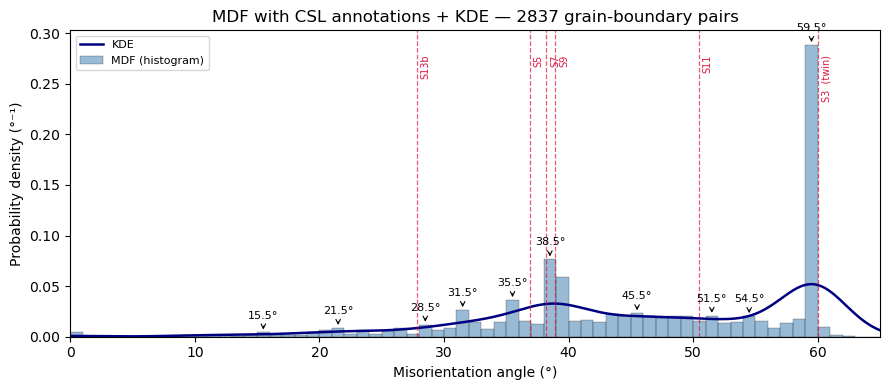

In [6]:
rg = repgen2d.from_tgs(tgs=None, tgstype='ebsd2d', ebsd_file=CTF_FILE)
rg.set_ebsd_step(rdr.step_size)
rg.clean_and_rechar_from_rdr(rdr, connectivity=4, min_grain_size=MIN_GRAIN_SIZE)
rg.compute_ebsd_stats()

mdf, peaks = rg.compute_mdf_ebsd()

### S6  Select MDF peaks of interest

In [7]:
selected_peaks = rg.select_mdf_peaks(peaks)

Select which MDF peaks to retain for downstream analysis:


### S7  Plot MDF with selected peaks

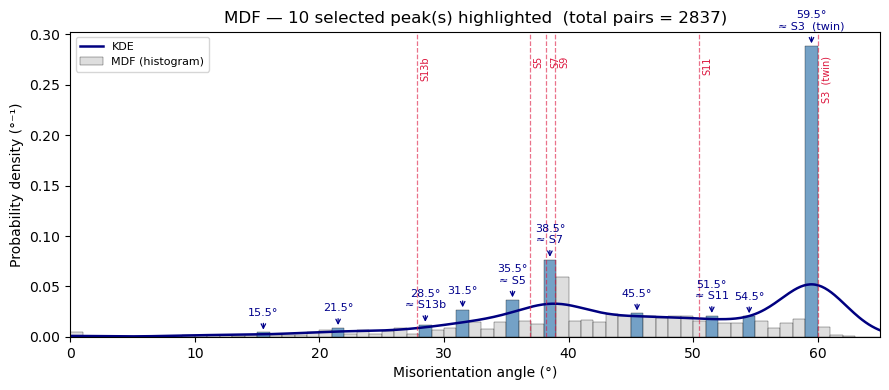

Selected peak angles : [15.5, 21.5, 28.5, 31.5, 35.5, 38.5, 45.5, 51.5, 54.5, 59.5]


In [8]:
rg.plot_mdf_selected(mdf, peaks, selected_peaks)

### S8  Segregate CSL pairs and visualise

CSL type            ref °   pairs   grains
──────────────────────────────────────────
S13b                27.80      84      145
S5                  36.87     343      453
S7                  38.21     466      597
S11                 50.48     211      317
S3  (twin)          60.00     898      948


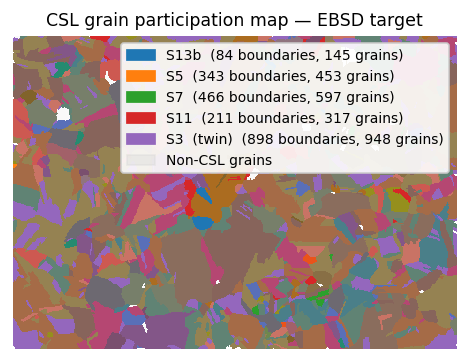

In [9]:
csl_grains = rg.segregate_csl_pairs(mdf, selected_peaks, peaks['csl'], peaks['csl_tol'])
rg.see_csl_grain_map(csl_grains, figsize=(6, 3), dpi=125)

### S9  CSL volume fractions

CSL type            ref °   grains    pixels   VF (indexed)   VF (total)
──────────────────────────────────────────────────────────────────────
S13b                27.80      145     50119        28.09%      28.07%
S5                  36.87      453    103827        58.18%      58.15%
S7                  38.21      597    132019        73.98%      73.93%
S11                 50.48      317     94818        53.13%      53.10%
S3  (twin)          60.00      948    165325        92.64%      92.59%


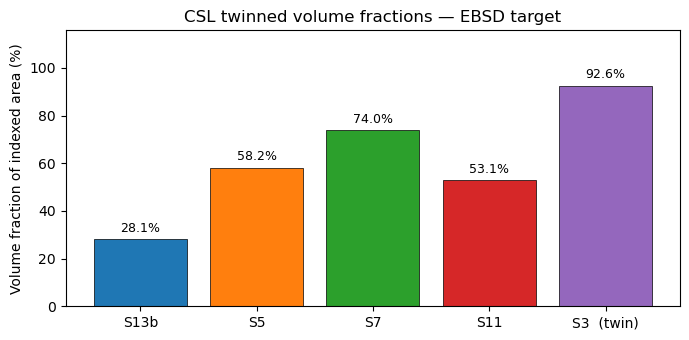

In [10]:
cslvf = rg.compute_csl_volume_fractions(csl_grains)

### S10  Identify parent grains

CSL type            ref °   pairs   pure parents   pure twins   intermediates
───────────────────────────────────────────────────────────────────────────
S13b                27.80      84             67           74               4
S5                  36.87     343            178          214              61
S7                  38.21     466            212          300              85
S11                 50.48     211            132          158              27
S3  (twin)          60.00     898            243          497             208


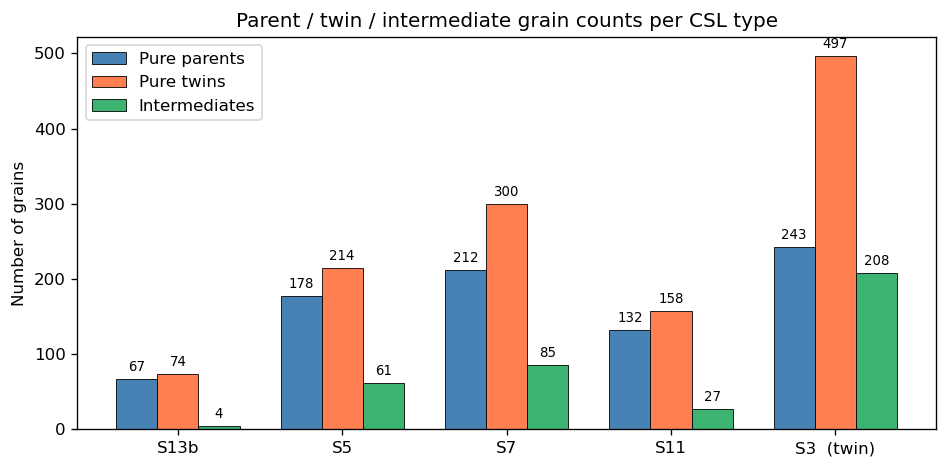

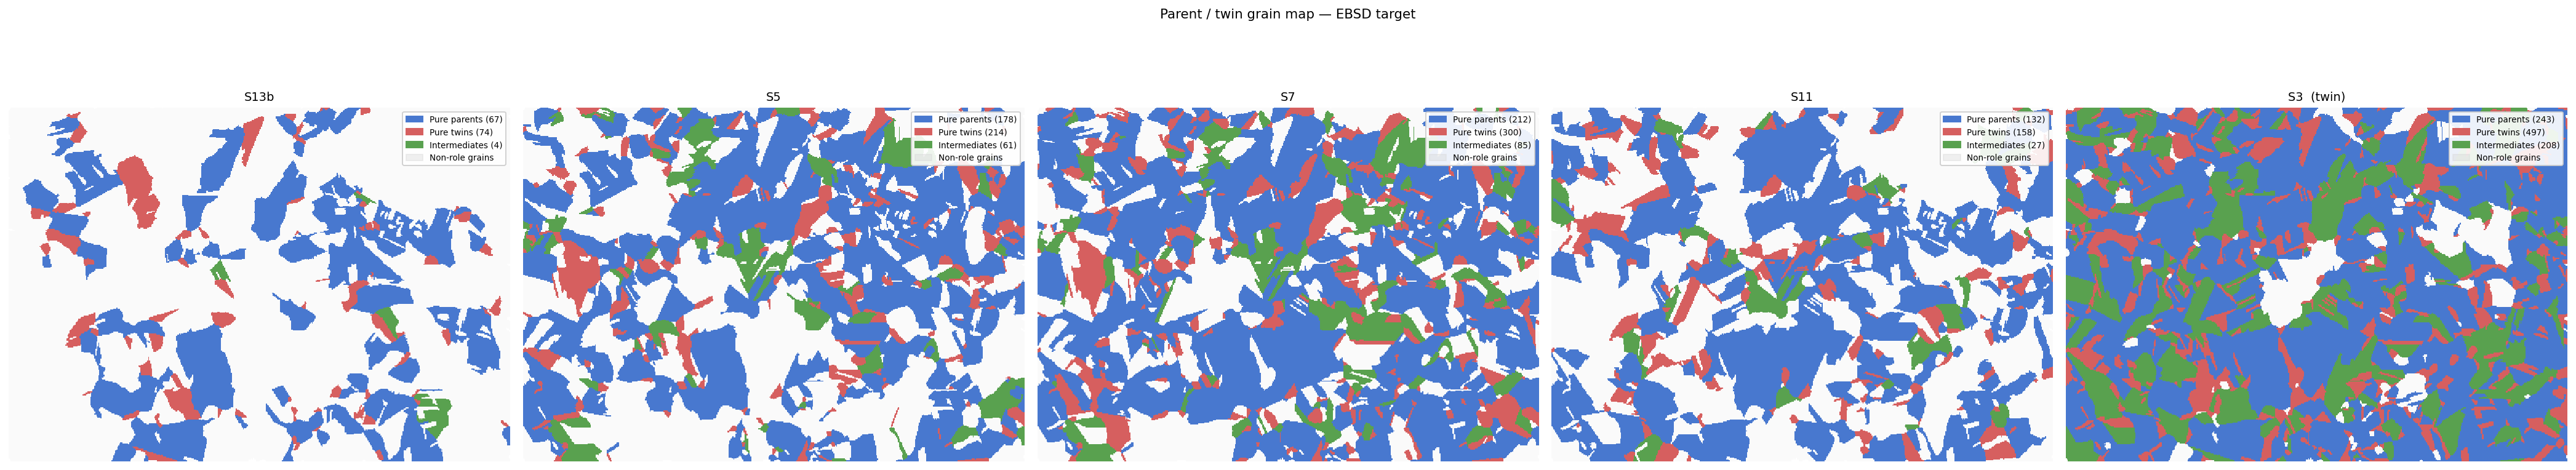

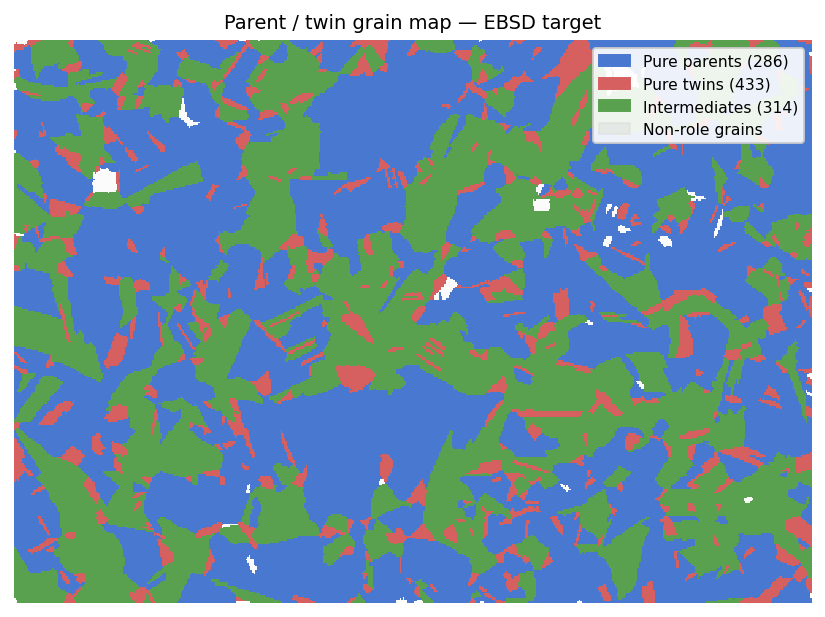

In [11]:
parent_info = rg.identify_parent_grains(csl_grains, plot_parent_twin_maps=True, plot_combined_parent_twin_map=True)

### S11  EBSD twin area fractions - compute

In [12]:
tvf = rg.compute_ebsd_tvf(parent_info)
print(f"CSL label                  : {tvf['csl_label']}")
print(f"Overall twin area fraction : {tvf['overall_twin_frac']:.4f}")
print(f"  Pure parents             : {tvf['pure_parent_frac']:.4f}")
print(f"  Primary twins (1st gen)  : {tvf['primary_twin_frac']:.4f}")
print(f"  Secondary twins (2nd gen): {tvf['secondary_twin_frac']:.4f}")
print(f"  Intermediate twins       : {tvf['intermediate_frac']:.4f}")
print(f"  No-role grains           : {tvf['non_role_frac']:.4f}")
print(f"  {'-' * 41}")
print(f"  Sum check                : {tvf['overall_twin_frac'] + tvf['pure_parent_frac'] + tvf['non_role_frac']:.4f}")

compute_ebsd_tvf: auto-selected CSL label  → "S13b"
  Available labels: ['S13b', 'S5', 'S7', 'S11', 'S3  (twin)']
CSL label                  : S13b
Overall twin area fraction : 0.0574
  Pure parents             : 0.2234
  Primary twins (1st gen)  : 0.0478
  Secondary twins (2nd gen): 0.0014
  Intermediate twins       : 0.0082
  No-role grains           : 0.7191
  -----------------------------------------
  Sum check                : 1.0000


### S12  EBSD twin area fractions - plot

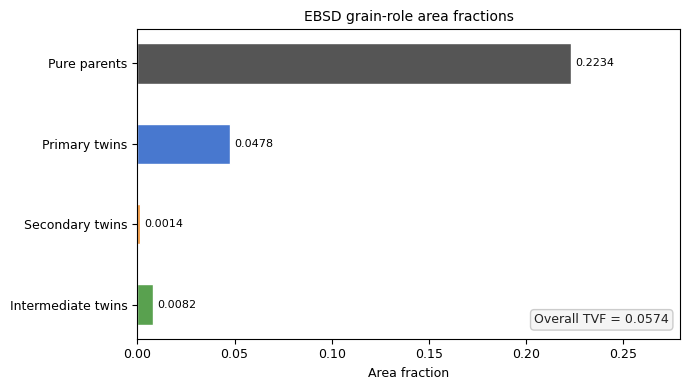

In [13]:
rg.plot_ebsd_tvf(tvf)

### S13  Build merged EBSD labelled feature image (LFI)

[merge_info]  merged grains: 157  |  with twins: 132  |  twin-hosting fraction: 0.8408


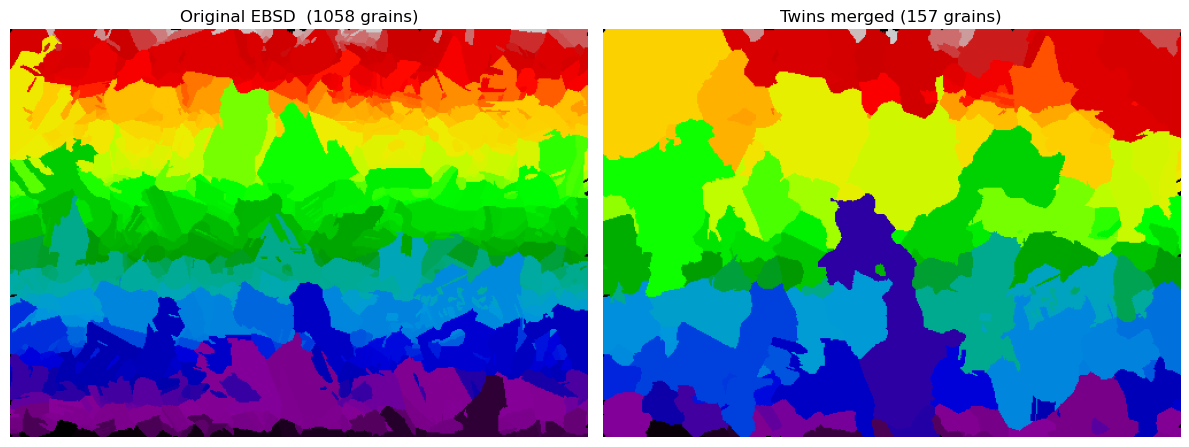

In [14]:
rg.build_merged_ebsd_lfi(parent_info)

### S14  Merge provenance

In [15]:
print(f"Merged grains total    : {rg.merge_info['n_merged_total']}")
print(f"Grains with twins      : {rg.merge_info['n_hosting_grains']}")
print(f"Twin-hosting fraction  : {rg.merge_info['twin_hosting_fraction']:.4f}")

Merged grains total    : 157
Grains with twins      : 132
Twin-hosting fraction  : 0.8408


### S14b  EBSD parent-state MDF (merged: twins absorbed into parents)
Used as the pre-twin comparison reference in S27.  The full `mdf` (twins present, Sigma3 peak at ~60 deg) is reserved for the post-twin comparison in S33.

In [16]:
from upxo.xtalphy.crystal_orientation import grain_avg_quats, compute_mdf_from_quats
from upxo.gsdataops.gid_ops import find_neighs2d

# Grain-average quaternions for the merged (parent-only) EBSD structure
ebsd_gids_m, ebsd_q_m = grain_avg_quats(rg.lfi_ebsd_merged, rg.quat_ebsd)
gid2q_m = {int(g): ebsd_q_m[i] for i, g in enumerate(ebsd_gids_m)}

# Broadcast back to a per-pixel quaternion field
import numpy as np
quat_merged_field = np.zeros(rg.lfi_ebsd_merged.shape + (4,), dtype=np.float64)
for gid, q in gid2q_m.items():
    quat_merged_field[rg.lfi_ebsd_merged == gid] = q

# Neighbour graph and MDF for the merged structure
neigh_m_raw = find_neighs2d(rg.lfi_ebsd_merged.astype(np.int32), conn=4)
neigh_m = {int(g): [int(n) for n in ns] for g, ns in neigh_m_raw.items()}
mdf_merged = compute_mdf_from_quats(
    rg.lfi_ebsd_merged, quat_merged_field, neigh_m, n_bins=65, angle_range=(0.0, 65.0))

print(f'EBSD merged (parent-state) MDF - mean: {mdf_merged["mean_angle"]:.2f} deg, '
      f'n_pairs: {mdf_merged["n_pairs"]}')
print(f'EBSD full (with twins)    MDF - mean: {mdf["mean_angle"]:.2f} deg')
print('mdf_merged will be used for pre-twin comparison (S27).')
print('mdf (full) will be used for post-twin comparison (S33).')

EBSD merged (parent-state) MDF - mean: 39.10 deg, n_pairs: 363
EBSD full (with twins)    MDF - mean: 46.18 deg
mdf_merged will be used for pre-twin comparison (S27).
mdf (full) will be used for post-twin comparison (S33).


## Part B - Grain role property analysis (twin GS)

### S15  Select GS properties for twin analysis

In [17]:
twinPropSelection = rg.selectProps_twinGS()

### S16  Read selected properties and view distributions

Properties : ['area']
Groups     : ['pure_parents', 'pure_twins', 'intermediates', 'non_role']


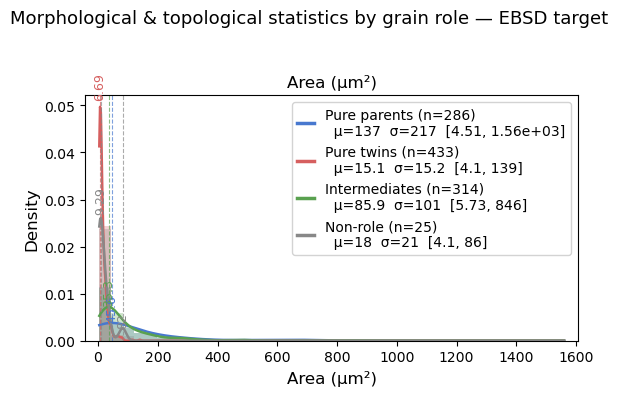

In [18]:
twinProps = rg.readProps_twinGS(twinPropSelection)
rg.see_grain_role_property_stats(parent_info, twinProps)

## Part B2 - EBSD twin VF partition (2a outward / 2b inward)
Classify each EBSD pure twin grain geometrically as:
- **Type 2a** (outward): shares a boundary with at least one pure-parent grain →
  will be carved from the parent grain at the primary-twin interface
- **Type 2b** (inward): fully surrounded by intermediate grains →
  will be carved from within the primary twin lamella

This partitioning replaces the `PROB_SECONDARY_OUTWARD_TWIN_NUCLEATION`
probability knob used in the probVf pipeline.

In [19]:
# EBSD geometric VF partition -- used for 2a/2b secondary split geometry only
vf_partition = rg.compute_ebsd_twin_vf_partition(parent_info, tvf)

# -- 2D -> 3D stereological correction ----------------------------------------
# VF_PARTITION_2D_TO_3D_SCALE = 1.00 (Cavalieri principle: 2D area = 3D VF for
# randomly oriented lamellae; no correction needed for FCC {111} twins).
VF_PARTITION_2D_TO_3D_SCALE = 1.00

# -- Stage-1 target: primary twin lamellae ------------------------------------
# Use primary_twin_frac + intermediate_frac from compute_ebsd_tvf (the actual
# large primary lamellae identified by the CSL analysis).  Do NOT use
# vf_partition["tvf_stage1"] which equals vf_int + vf_2b (nearly zero here
# because primary lamellae appear as pure_twins adjacent to pure_parents,
# landing in vf_2a rather than vf_int or vf_2b).
_prim_frac = tvf.get('primary_twin_frac', 0.0)
_int_frac  = tvf.get('intermediate_frac', 0.0)
_sec_frac  = tvf.get('secondary_twin_frac', 0.0)
TVF_STAGE1 = (_prim_frac + _int_frac) * VF_PARTITION_2D_TO_3D_SCALE

# -- Stage-2 targets: secondary twins (2a outward + 2b inward) ----------------
# Total secondary = secondary_twin_frac from compute_ebsd_tvf.
# Split by prob_secondary_outward from partition (note: this probability is
# approximate as vf_2a from the partition includes primary twins too, biasing
# it toward 1.0; conservative 50/50 split used if prob > 0.95).
_prob_outward_ebsd = vf_partition["prob_secondary_outward"]
if _prob_outward_ebsd > 0.95:
    _prob_outward_ebsd = 0.5   # partition result unreliable; fall back to 50/50
TVF_SECONDARY_2A = _sec_frac * _prob_outward_ebsd         * VF_PARTITION_2D_TO_3D_SCALE
TVF_SECONDARY_2B = _sec_frac * (1.0 - _prob_outward_ebsd) * VF_PARTITION_2D_TO_3D_SCALE

print(f"Primary twin frac (EBSD)         : {_prim_frac:.4f}")
print(f"Intermediate frac (EBSD)         : {_int_frac:.4f}")
print(f"Secondary twin frac (EBSD)       : {_sec_frac:.4f}")
print(f"Stage-1 carving target           : {TVF_STAGE1:.4f}  (scaled x{VF_PARTITION_2D_TO_3D_SCALE})")
print(f"TVF_SECONDARY_2A                 : {TVF_SECONDARY_2A:.4f}")
print(f"TVF_SECONDARY_2B                 : {TVF_SECONDARY_2B:.4f}")
print(f"Expected total MC VF             : {TVF_STAGE1 + TVF_SECONDARY_2A + TVF_SECONDARY_2B:.4f}")
print(f"EBSD overall_twin_frac           : {tvf['overall_twin_frac']:.4f}")
print(f"prob_secondary_outward (used)    : {_prob_outward_ebsd:.3f}")


compute_ebsd_twin_vf_partition  (CSL: S13b)
  Intermediates (primary twins) :    4  VF=0.0082
  Type-2a pure twins (outward)  :   73  VF=0.0483
  Type-2b pure twins (inward)   :    1  VF=0.0009
  SGC Stage-1 carving target    :       VF=0.0091  (intermediate + 2b)
  Derived prob_secondary_outward: 0.982
Primary twin frac (EBSD)         : 0.0478
Intermediate frac (EBSD)         : 0.0082
Secondary twin frac (EBSD)       : 0.0014
Stage-1 carving target           : 0.0561  (scaled x1.0)
TVF_SECONDARY_2A                 : 0.0007
TVF_SECONDARY_2B                 : 0.0007
Expected total MC VF             : 0.0574
EBSD overall_twin_frac           : 0.0574
prob_secondary_outward (used)    : 0.500


## Part C - 3D SGC generation and base setup

> **Nomenclature note**: Throughout this notebook the term
> **SGC (Synthetic Grain Structure)** is used in place of the
> conventional "MC" (Monte Carlo) abbreviation.
> SGC denotes any computationally generated grain structure,
> making the pipeline agnostic of the specific generation
> algorithm (Monte Carlo Potts, phase-field, Voronoi, etc.).
> The UPXO library class that generates the SGC here is
> `mcgs` (Monte Carlo Grain Structure) — its internal name
> is unchanged; only the conceptual labelling in this notebook
> adopts the SGC convention.

### S17  Configuration

In [20]:
# -- 3D MC ---------------------------------------------------------------
INPUT_DASHBOARD = r'C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\twinned3d-1.xls'
MC_TIME_START    = 2
MC_TIME_END      = -1
MC_TIME_STEP     = 2
print('Configuration loaded.')

Configuration loaded.


### S18  Run 3D SGC simulation

In [21]:
pxt = mcgs(study='independent', input_dashboard=INPUT_DASHBOARD)
print(pxt)
print('Simulating...')
pxt.simulate(verbose=False)
print(f'Simulation complete. Temporal slices: {len(pxt.m)}')

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\twinned3d-1.xls
Algo_hops details
(('300b', 100),)
[False]
x:(0.0,100.0,1.0), y:(0.0,100.0,1.0), z:(0.0,100.0,1.0).
Simulating...

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 24
     Dimensionality: 3
Using ALG-300b
////////////////////////////////
Initiating grain growth
----------------------------------------
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 stor

### S19  Select temporal slice and build TwinnedSimple3DBase

In [22]:
# -- Temporal slice sampling config ------------------------------------
MC_SLICE_START          = 10    # starting positional index into pxt.m
MC_SLICE_STEP           = 5     # sample every N-th slice

# -- 2D-equivalent grain count config (fair comparison with EBSD) ------
# EBSD gives a 2D cross-section; we compare to the mean grain count
# across 2D slices extracted from the 3D MC structure.
MC_COMPARE_N_SLICES     = 5             # slices per axis
MC_COMPARE_AXES         = ['x', 'y', 'z']  # axes to include

n_shown = len(range(MC_SLICE_START, len(pxt.m), MC_SLICE_STEP))
n_total_slices = MC_COMPARE_N_SLICES * len(MC_COMPARE_AXES)
print(f'Sampling {n_shown} temporal slices from pxt.m[{MC_SLICE_START}::step={MC_SLICE_STEP}]')
print(f'Each slice scored by mean 2D grain count across {n_total_slices} slices '
      f'({MC_COMPARE_N_SLICES} per axis: {MC_COMPARE_AXES})')

Sampling 23 temporal slices from pxt.m[10::step=5]
Each slice scored by mean 2D grain count across 15 slices (5 per axis: ['x', 'y', 'z'])


In [23]:
from upxo.pxtal.twinned_simple_3d import TwinnedSimple3DBase

# EBSD reference parent grain count (from Part A)
ebsd_n_parents = len(parent_info[tvf['csl_label']]['pure_parents'])

# Rank slices by 2D-equivalent grain count and display single-select widget
rank_info = TwinnedSimple3DBase.rank_temporal_slices_by_n(
    pxt,
    start=MC_SLICE_START,
    step=MC_SLICE_STEP,
    ebsd_n_parents=ebsd_n_parents,
    n_comparison_slices=MC_COMPARE_N_SLICES,
    comparison_axes=MC_COMPARE_AXES,
)
tslice_wdg = TwinnedSimple3DBase.select_temporal_slice(rank_info, ebsd_n_parents)

In [24]:
# Read selected key from widget above
tslice_key = tslice_wdg.value
print(f'Selected temporal slice: t={tslice_key}')

base = TwinnedSimple3DBase.from_mcgs(pxt, tslice_key, rng_seed=0)
base.char_morphology(volnv=True, eqdia=True)
print(base)

Selected temporal slice: t=120
---------------------------------------- 
Finding grains.
No. of grains detected = 861
---------------------------------------- 
Setting PyVista grid.
---------------------------------------- 
Adding scalar field: lgi to PyVista grid self.pvgrid.
Access: self.pvgrid.cell_data['lgi']

Finding voxel locations of grains in lgi
gid: 1 of 861 grains
gid: 44 of 861 grains
gid: 87 of 861 grains
gid: 130 of 861 grains
gid: 173 of 861 grains
gid: 216 of 861 grains
gid: 259 of 861 grains
gid: 302 of 861 grains
gid: 345 of 861 grains
gid: 388 of 861 grains
gid: 431 of 861 grains
gid: 474 of 861 grains
gid: 517 of 861 grains
gid: 560 of 861 grains
gid: 603 of 861 grains
gid: 646 of 861 grains
gid: 689 of 861 grains
gid: 732 of 861 grains
gid: 775 of 861 grains
gid: 818 of 861 grains
gid: 861 of 861 grains

Finding normal and extended spatial bounds of all grains.
Completed ----------------------------------------
----------------------------------------
-------------

### S20  Allocate twin hosts

In [25]:
# -- Host allocation configuration ---------------------------------------------
HOST_FRACTION_2D_TO_3D_SCALE_FACTOR = 1.00

# Composite ranking weight: 1.0 = volume only, 0.5 = equal vol+adjacency, 0.0 = adjacency only
HOST_RANKING_VOLUME_WEIGHT          = 0.5

# -- Spatial dispersal parameters (allocate_twin_hosts_spatial) ----------------
# Pool A: MIS_FRACTION of n_target drawn from maximal independent set
# (non-adjacent hosts -> no twin-twin contacts).
MIS_FRACTION   = 0.80   # 80% spatially dispersed, 20% allowed near-mean pairs

# Pool B (remaining 20%): size measure and tolerance for 'near mean grain size'
# Size metric options:
#   'vol_vox'  - grain volume in voxels (integer count)
#   'vol_um3'  - grain volume in um3 (vol_vox * voxel_size^3)
#   'eqdia_um' - sphere-equivalent diameter in um = (6*vol_um3/pi)^(1/3)
POOL_B_SIZE_MEASURE = 'eqdia_um'

# Tolerance band: grains qualify if |size - mean(size)| <= N_STD * std(size).
# 1.0 = +-1 std dev of the eqdia_um distribution (~68% of grains qualify).
POOL_B_N_STD        = 1.0

MIS_RUNS   = 25     # random MIS trials; largest result kept
MIS_SEED   = 0      # base seed for reproducibility

target_frac = rg.merge_info['twin_hosting_fraction']
_ = base.allocate_twin_hosts_spatial(
    target_hosting_fraction             = target_frac,
    min_host_voxels                     = 20,
    host_fraction_2d_to_3d_scale_factor = HOST_FRACTION_2D_TO_3D_SCALE_FACTOR,
    host_ranking_volume_weight          = HOST_RANKING_VOLUME_WEIGHT,
    mis_fraction                        = MIS_FRACTION,
    pool_b_size_measure                 = POOL_B_SIZE_MEASURE,
    pool_b_n_std                        = POOL_B_N_STD,
    mis_runs                            = MIS_RUNS,
    seed                                = MIS_SEED,
)


TwinnedSimple3DBase.allocate_twin_hosts_spatial:
  EBSD 2D hosting fraction   : 0.8408
  3D effective target        : 0.8408
  n_target                   : 645
  MIS best size              : 173  (from 25 runs, seed base 0)
  Pool A (MIS, 80%)         : 173 grains
  Pool B size measure        : eqdia_um  (sphere-equiv. diameter in μm; voxel=1.0000 μm)
  Pool B tolerance           : ±1.0 std  (mean=11.3  std=5.22  band [6.08, 16.5])
  Pool B candidates          : 418 eligible
  Pool B (near-mean pairs)   : 418 grains selected
  Total hosts                : 591
  Non-host grains            : 270
  Achieved hosting fraction  : 0.4388


## Part D - Pre-twin morphological representativeness

### S21  Configuration

In [26]:
N_SLICES_X    = 10
N_SLICES_Y    = 10
N_SLICES_Z    = 10
TEST_ALONG_X  = True   # set False to skip X-axis slice validation
TEST_ALONG_Y  = True
TEST_ALONG_Z  = True
P_PERCENTAGE  = 60.0   # % of slices that must pass per axis

ax_str = ','.join([ax for ax, t in zip('XYZ', [TEST_ALONG_X, TEST_ALONG_Y, TEST_ALONG_Z]) if t])
print(f'Slice config: {N_SLICES_X}x{N_SLICES_Y}x{N_SLICES_Z} slices  '
      f'axes=({ax_str})  threshold {P_PERCENTAGE}%')

Slice config: 10x10x10 slices  axes=(X,Y,Z)  threshold 60.0%


### S22  Build EBSD reference grain-size distribution

In [27]:
from upxo.charops.mchar import get_grain_size_distribution_from_slice

ebsd_areas = get_grain_size_distribution_from_slice(rg.lfi_ebsd_merged)
print(f'EBSD reference: {len(ebsd_areas)} grains, '
      f'mean area = {ebsd_areas.mean():.1f} px')

EBSD reference: 157 grains, mean area = 1136.6 px


### S23  Validate morphological representativeness

In [28]:
from upxo.pxtal.twinned_simple_3d import RepresentativenessValidator3D

validator = RepresentativenessValidator3D(
    n_slices_x=N_SLICES_X, n_slices_y=N_SLICES_Y, n_slices_z=N_SLICES_Z,
    p_percentage=P_PERCENTAGE, wasserstein_threshold=0.5,
)
validator.validate_morphological(base.lgi, ebsd_areas)
print(validator.report())

3D Representativeness Validation
X-axis: 10/10 (100.0%) [ACCEPTED]
Y-axis: 10/10 (100.0%) [ACCEPTED]
Z-axis: 10/10 (100.0%) [ACCEPTED]

Overall 3D acceptance: YES
Threshold: 60.0% per axis


### S24  Visualise per-axis pass rates

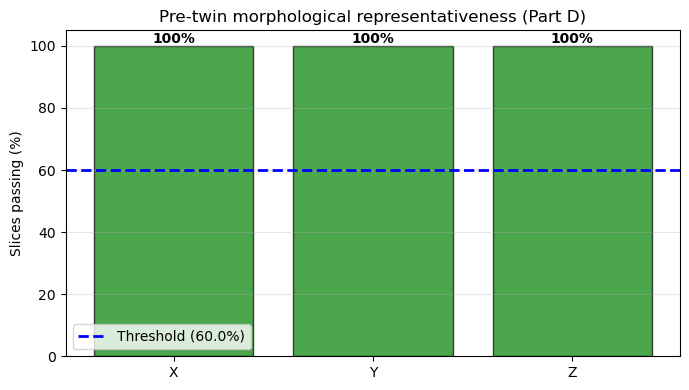

In [29]:
ax_names = list(validator.axis_acceptance.keys())
pct_pass = [validator.axis_acceptance[a]['pct_pass'] for a in ax_names]
colors   = ['green' if validator.axis_acceptance[a]['accepted'] else 'red' for a in ax_names]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(ax_names, pct_pass, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(P_PERCENTAGE, color='blue', linestyle='--', linewidth=2, label=f'Threshold ({P_PERCENTAGE}%)')
ax.set_ylabel('Slices passing (%)')
ax.set_title('Pre-twin morphological representativeness (Part D)')
ax.set_ylim(0, 105)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, pct in zip(bars, pct_pass):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{pct:.0f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

## Part E - Conflict-free orientation assignment

### S25  Build neighbour graph and EBSD orientation pools

In [30]:
from upxo.pxtal.twinned_simple_3d import OrientationAssigner3D

# -- Orientation assignment mode -------------------------------------------
# Level 0    conflict_free          independent sampling
# Level 1    paired_pool            EBSD adjacent pair conditioned
# Level 2a   mdf_conditioned_pairs  L1 pairs + MDF angle bin conditioning
# Level 2b   mdf_analytical         analytical MDF-targeted (recommended)
# Level 3a   mrf_gibbs              MRF via Gibbs sampling
# Level 3b   mrf_map                MRF via MAP/SA (SA: deterministic, T-annealed)
ORIENTATION_ASSIGNMENT_MODE  = 'mdf_analytical'
PAIR_SIMILARITY_DEG          = 25.0  # Levels 1/2a: similarity threshold
# Seed for stochastic sampling (Levels 1, 2a, 2b, 3a).
# Change for different realisations; average MDFs for best estimate.
ORIENTATION_RNG_SEED         = 0

# -- MRF Gibbs/MAP parameters (Levels 3a/3b) ------------------------------
MRF_MAX_SWEEPS      = 20      # hard stop on Gibbs/SA sweeps
MRF_EPS_CONVERGENCE = 0.3     # W1 between consecutive sweeps (deg)
MRF_EPS_QUALITY     = 1.5     # W1 to EBSD reference (deg)
MRF_INIT_MODE       = "mdf_analytical"   # warm-start level
MRF_KDE_THRESHOLD   = None    # None = auto; int = explicit min-bin-count
MRF_BILATERAL_SYMMETRY = False   # True: 576-op bilateral (no gain for cubic); False: 24-op left-only (default)
# NOTE: for cubic symmetry (FCC Cu, BCC steel, FCC austenite) bilateral=True
# adds 30x cost with zero accuracy improvement. Only meaningful for lower-symmetry systems.

# -- MRF MAP/SA parameters (Level 3b only) --------------------------------
MRF_SA_T_START = 5.0    # initial SA temperature (high T = broad exploration)
MRF_SA_T_END   = 0.05   # final SA temperature (low T = near-deterministic MAP)

oriassign = OrientationAssigner3D(
    base,
    orientation_assignment_mode = ORIENTATION_ASSIGNMENT_MODE,
    pair_similarity_deg         = PAIR_SIMILARITY_DEG,
    mrf_max_sweeps              = MRF_MAX_SWEEPS,
    mrf_eps_convergence         = MRF_EPS_CONVERGENCE,
    mrf_eps_quality             = MRF_EPS_QUALITY,
    mrf_init_mode               = MRF_INIT_MODE,
    mrf_kde_threshold           = MRF_KDE_THRESHOLD,
    mrf_bilateral_symmetry      = MRF_BILATERAL_SYMMETRY,
    mrf_sa_t_start              = MRF_SA_T_START,
    mrf_sa_t_end                = MRF_SA_T_END,
    rng_seed                    = ORIENTATION_RNG_SEED)

oriassign.build_neighbour_graph(connectivity=6)

csl_label = tvf['csl_label']
oriassign.build_ebsd_pools(rg.lfi_ebsd, rg.quat_ebsd, parent_info, csl_label)

if ORIENTATION_ASSIGNMENT_MODE != 'conflict_free':
    oriassign.build_adjacency_model(
        rg, parent_info, csl_label, mdf_ref=mdf_merged)

# -- Configuration summary -------------------------------------------------
print()
print('Orientation assignment configuration:')
print(f'  Mode              : {ORIENTATION_ASSIGNMENT_MODE}')
print(f'  RNG seed          : {ORIENTATION_RNG_SEED}')
if ORIENTATION_ASSIGNMENT_MODE not in ('conflict_free',):
    print(f'  Pair similarity   : {PAIR_SIMILARITY_DEG} deg')
if ORIENTATION_ASSIGNMENT_MODE in ('mrf_gibbs', 'mrf_map'):
    print(f'  MRF init mode     : {MRF_INIT_MODE}')
    print(f'  MRF max sweeps    : {MRF_MAX_SWEEPS}')
    print(f'  MRF eps_conv      : {MRF_EPS_CONVERGENCE} deg')
    print(f'  MRF eps_quality   : {MRF_EPS_QUALITY} deg')
    print(f'  Bilateral sym.    : {MRF_BILATERAL_SYMMETRY}')
if ORIENTATION_ASSIGNMENT_MODE == 'mrf_map':
    print(f'  SA T_start        : {MRF_SA_T_START}')
    print(f'  SA T_end          : {MRF_SA_T_END}')


OrientationAssigner3D: mode = "mdf_analytical"
OrientationAssigner3D: neighbour graph (6-connected): 861 grains, 4740 edges
.. User texture information standardisation.

Generating orientations for cryst. texture

.. Caclulating TC wise orientation counts
Building TEX dictionary template

.. TEXTURE INSTANCE NUMBER: 1 of 1

.. Generating ori. clusters around mean texture components
Calculating misorientations across all symmetric equivalents of 'goss' texture component: 2064 oris
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 3 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 6 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 9 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 12 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 15 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 18 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 21 of 24
.. TC: '{tc_comp}'. MO calcu

### S26  Assign host and non-host orientations

In [31]:
oriassign.assign_host_orientations()
oriassign.assign_nonhost_orientations()
oriassign.check_conflicts()


OrientationAssigner3D [L2b mdf_analytical]: 591 host orientations  analytical: 503  fallback: 88
OrientationAssigner3D [L2b mdf_analytical]: 270 non-host orientations  analytical: 269  fallback: 1
OrientationAssigner3D: conflict check [PASS] -- 0 adjacent identical-orientation pairs


0

### S27  Pre-twin MDF verification

SGC pre-twin 3D MDF      - mean: 38.31 deg, n_pairs: 4740
EBSD parent-state MDF    - mean: 39.10 deg


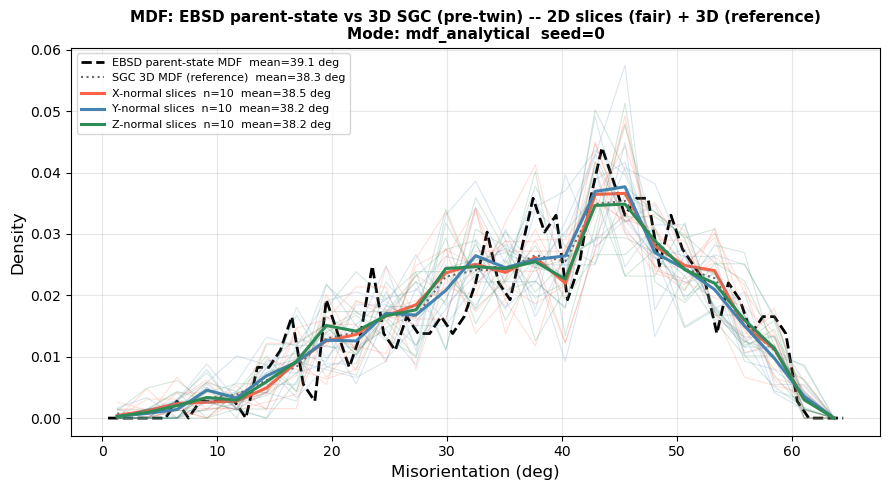

In [32]:
from upxo.gsdataops.gid_ops import find_neighs2d
from upxo.xtalphy.crystal_orientation import compute_mdf_from_quats
from upxo.gsdataops.grid_ops import section_from_3d

# ── 3D overall SGC pre-twin MDF ─────────────────────────────────────────
sgc_mdf_pre = oriassign.compute_mdf(n_bins=25, angle_range=(0.0, 65.0))
print(f'SGC pre-twin 3D MDF      - mean: {sgc_mdf_pre["mean_angle"]:.2f} deg, '
      f'n_pairs: {sgc_mdf_pre["n_pairs"]}')
print(f'EBSD parent-state MDF    - mean: {mdf_merged["mean_angle"]:.2f} deg')

# ── 2D slice MDFs from SGC pre-twin structure ────────────────────────────
# Build per-voxel quaternion field from oriassign.all_grain_orientations
quat_3d_pretwin = np.zeros(base.lgi.shape + (4,), dtype=np.float64)
for _gid, _q in oriassign.all_grain_orientations.items():
    quat_3d_pretwin[base.lgi == _gid] = _q

axis_colors = {'X': 'tomato', 'Y': 'steelblue', 'Z': 'seagreen'}
axis_cfg    = [
    ('X', 0, N_SLICES_X, TEST_ALONG_X),
    ('Y', 1, N_SLICES_Y, TEST_ALONG_Y),
    ('Z', 2, N_SLICES_Z, TEST_ALONG_Z),
]

fig, ax = plt.subplots(figsize=(9, 5))

# EBSD reference (black dashed) — 2D parent-state MDF
ax.plot(mdf_merged['hist_bin_centers'], mdf_merged['hist_density'],
        color='black', lw=2, linestyle='--',
        label=f'EBSD parent-state MDF  mean={mdf_merged["mean_angle"]:.1f} deg')

# SGC 3D MDF (grey solid) — for reference, NOT the fair comparison
ax.plot(sgc_mdf_pre['hist_bin_centers'], sgc_mdf_pre['hist_density'],
        color='dimgray', lw=1.5, linestyle=':',
        label=f'SGC 3D MDF (reference)  mean={sgc_mdf_pre["mean_angle"]:.1f} deg')

# 2D slice MDFs per axis (thin individual + thick mean)
for axis_name, ax_int, n_slices, enabled in axis_cfg:
    if not enabled:
        continue
    color = axis_colors[axis_name]
    domain_size = base.lgi.shape[ax_int]
    slice_indices = np.linspace(0, domain_size - 1, n_slices, dtype=int)

    densities = []
    bin_centers = None

    for slice_idx in slice_indices:
        lgi_2d  = section_from_3d(base.lgi, axis=ax_int, location=int(slice_idx))
        quat_2d = quat_3d_pretwin[
            slice_idx, :, :] if ax_int == 0 else (
            quat_3d_pretwin[:, slice_idx, :] if ax_int == 1 else
            quat_3d_pretwin[:, :, slice_idx])
        if lgi_2d.max() <= 0:
            continue
        try:
            neigh_raw = find_neighs2d(lgi_2d.astype(np.int32), conn=4)
            neigh     = {int(g): [int(n) for n in ns] for g, ns in neigh_raw.items()}
            smdf      = compute_mdf_from_quats(
                lgi_2d, quat_2d, neigh, n_bins=25, angle_range=(0.0, 65.0))
            densities.append(smdf['hist_density'])
            bin_centers = smdf['hist_bin_centers']
            ax.plot(smdf['hist_bin_centers'], smdf['hist_density'],
                    color=color, alpha=0.2, lw=0.8)
        except Exception:
            pass

    if densities and bin_centers is not None:
        mean_d = np.mean(densities, axis=0)
        mean_angle = float(np.sum(bin_centers * mean_d) / np.sum(mean_d)) if mean_d.sum() > 0 else 0
        ax.plot(bin_centers, mean_d, color=color, lw=2.2,
                label=f'{axis_name}-normal slices  n={len(densities)}  '
                      f'mean={mean_angle:.1f} deg')

ax.set_xlabel('Misorientation (deg)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
# Build informative second title line from current config
_mode_info = f'Mode: {ORIENTATION_ASSIGNMENT_MODE}  seed={ORIENTATION_RNG_SEED}'
if ORIENTATION_ASSIGNMENT_MODE in ('paired_pool', 'mdf_conditioned_pairs'):
    _mode_info += f'  sim={PAIR_SIMILARITY_DEG} deg'
if ORIENTATION_ASSIGNMENT_MODE in ('mrf_gibbs', 'mrf_map'):
    _mode_info += f'  init={MRF_INIT_MODE}  sweeps<={MRF_MAX_SWEEPS}'
    _mode_info += f'  bilateral={MRF_BILATERAL_SYMMETRY}'
ax.set_title(
    'MDF: EBSD parent-state vs 3D SGC (pre-twin) -- 2D slices (fair) + 3D (reference)\n'
    + _mode_info,
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part F - Twin introduction and topology cleaning

### S28  EBSD twin thickness statistics

In [33]:
twin_thickness = rg.compute_mc_twin_thickness(parent_info)

  Twin thickness (minor_axis_length) and intercept statistics (EBSD):
  Metric                              Q1    Q2 (med)        Q3       IQR
  ──────────────────────────────────────────────────────────────────────
  Thickness (µm)                    2.16        3.42      5.99      3.83
  Intercept length (px)             1.00        1.00      8.00      7.00
  Abrupt twins: 599 / 901  (fraction = 0.669)
  N = 898  |  CV = 0.804  |  skewness = 1.997  |  kurtosis (excess) = 4.914


### S28b  EBSD twin thickness distribution
Histogram and KDE of the EBSD-measured twin lamella thickness.
Use this plot to decide whether the EBSD distribution is appropriate for the
MC domain, or whether a `TWIN_THICK_SCALE_FACTOR != 1.0` is needed in S29.

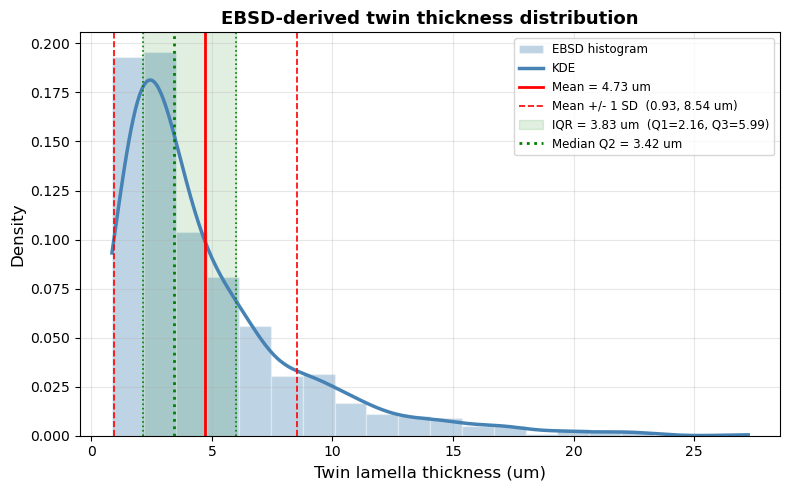

n = 898  |  Mean = 4.733 um  |  Std = 3.802 um  |  Q1/Q2/Q3 = 2.16/3.42/5.99 um  |  IQR = 3.829 um


In [34]:
from scipy.stats import gaussian_kde

thick_um = twin_thickness['thick_um']
if thick_um.size == 0:
    print('No twin thickness data available from EBSD.')
else:
    mean_t = float(np.mean(thick_um))
    std_t  = float(np.std(thick_um))
    q1     = float(np.percentile(thick_um, 25))
    q2     = float(np.percentile(thick_um, 50))
    q3     = float(np.percentile(thick_um, 75))
    iqr    = q3 - q1

    x_kde = np.linspace(thick_um.min(), thick_um.max(), 300)
    kde   = gaussian_kde(thick_um)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(thick_um, bins=20, density=True, alpha=0.35,
            color='steelblue', edgecolor='white', label='EBSD histogram')
    ax.plot(x_kde, kde(x_kde), color='steelblue', lw=2.5, label='KDE')

    # Mean and +/- 1 SD
    ax.axvline(mean_t, color='red', lw=2.0, linestyle='-',
               label=f'Mean = {mean_t:.2f} um')
    ax.axvline(mean_t - std_t, color='red', lw=1.2, linestyle='--',
               label=f'Mean +/- 1 SD  ({mean_t-std_t:.2f}, {mean_t+std_t:.2f} um)')
    ax.axvline(mean_t + std_t, color='red', lw=1.2, linestyle='--')

    # IQR band
    ax.axvspan(q1, q3, alpha=0.12, color='green',
               label=f'IQR = {iqr:.2f} um  (Q1={q1:.2f}, Q3={q3:.2f})')
    ax.axvline(q1, color='green', lw=1.2, linestyle=':')
    ax.axvline(q2, color='green', lw=2.0, linestyle=':',
               label=f'Median Q2 = {q2:.2f} um')
    ax.axvline(q3, color='green', lw=1.2, linestyle=':')

    ax.set_xlabel('Twin lamella thickness (um)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('EBSD-derived twin thickness distribution', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8.5, loc='upper right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'n = {thick_um.size}  |  '
          f'Mean = {mean_t:.3f} um  |  Std = {std_t:.3f} um  |  '
          f'Q1/Q2/Q3 = {q1:.2f}/{q2:.2f}/{q3:.2f} um  |  '
          f'IQR = {iqr:.3f} um')

In [35]:
# twin_thickness.keys()
# twin_thickness['std']

### S29  Introduce primary and secondary twins

In [36]:
from upxo.pxtal.twinned_simple_3d import TwinGenerator3D
import time

# -- SGC twin configuration (EBSD-partitioned mode) ----------------------------
# VF targets come from vf_partition (cell 38), not from probability knobs.
N_LAMELLAE_PER_HOST              = 10
TWIN_NUCLEATION_SITE             = 'random_gb'
TVF_TOLERANCE                    = 0.00   # 0 = stop at exactly tvf_stage1 target
TWIN_THICK_SCALE_FACTOR          = 1.25   # 1.0 = use raw EBSD thickness distribution
TVF_2D_TO_3D_SCALE_FACTOR        = 1.00   # fallback only; tvf_stage1 overrides for Stage 1
MAX_LAMELLA_THICKNESS_UM         = None   # None = uncapped
MAX_LAMELLA_VF_PER_HOST          = 0.70   # max twin volume as fraction of host grain volume
SCHMID_LOADING_DIRECTION         = (0., 0., 1.)
HOST_SCHMID_WEIGHT               = 0.3
USE_SCHMID_FOR_VARIANT_SEL       = True

print('[S29] Constructing TwinGenerator3D...')
twinmake = TwinGenerator3D(
    base,
    n_lamellae_per_host                   = N_LAMELLAE_PER_HOST,
    twin_nucleation_site                  = TWIN_NUCLEATION_SITE,
    tvf_tolerance                         = TVF_TOLERANCE,
    twin_orient_scatter_deg               = 0.3,
    meshing_route                         = 'conformal',
    twin_thick_scale_factor               = TWIN_THICK_SCALE_FACTOR,
    tvf_2d_to_3d_scale_factor             = TVF_2D_TO_3D_SCALE_FACTOR,
    max_lamella_thickness_um              = MAX_LAMELLA_THICKNESS_UM,
    max_lamella_vf_per_host               = MAX_LAMELLA_VF_PER_HOST,
    schmid_loading_direction              = SCHMID_LOADING_DIRECTION,
    host_schmid_weight                    = HOST_SCHMID_WEIGHT,
    use_schmid_for_variant_selection      = USE_SCHMID_FOR_VARIANT_SEL,
    prob_lamella_separated                = 0.3,
    prob_lamella_contacting               = 0.7,
    prob_secondary_outward_twinNucleation = _prob_outward_ebsd,
    prob_secondary_inward_twinNucleation  = 1.0 - _prob_outward_ebsd,
    rng_seed=123,
)
print('[S29] Step 1/3  TwinGenerator3D ready.')

# Stage 1: primary twin lamellae
_n_prim_target = f'{TVF_STAGE1:.4f}'
print(f'[S29] Step 2/3  Introducing primary twins  (stage-1 VF target = {_n_prim_target})...')
_t1 = time.perf_counter()
twinmake.introduce_primary_twins(
    oriassign.all_grain_orientations, twin_thickness,
    tvf=tvf, tvf_stage1=TVF_STAGE1)
_dt1 = time.perf_counter() - _t1
_n_prim = len(twinmake.primary_twin_quats)
print(f'[S29] Step 2/3  Primary twins done  ({_n_prim} twins  {_dt1:.1f}s)')

# Stage 2: secondary twins (2a outward + 2b inward)
_sec_info = f'2a={TVF_SECONDARY_2A:.4f}  2b={TVF_SECONDARY_2B:.4f}'
print(f'[S29] Step 3/3  Introducing secondary twins  ({_sec_info})...')
_t2 = time.perf_counter()
twinmake.introduce_secondary_twins(
    tvf, twin_thickness,
    tvf_2a=TVF_SECONDARY_2A, tvf_2b=TVF_SECONDARY_2B)
_dt2 = time.perf_counter() - _t2
_n_sec = len(twinmake.secondary_twin_quats)
print(f'[S29] Step 3/3  Secondary twins done  ({_n_sec} twins  {_dt2:.1f}s)')

print(f'[S29] Complete  total={_dt1+_dt2:.1f}s')
twinmake.print_summary()


[S29] Constructing TwinGenerator3D...
[S29] Step 1/3  TwinGenerator3D ready.
[S29] Step 2/3  Introducing primary twins  (stage-1 VF target = 0.0561)...
TwinGenerator3D WARNING: selected CSL "S13b" but only "S3  (twin)" is supported (Path A). Twin orientations will still use Sigma3.
  [S29] Building grain voxel index... done  861 grains  (0.2s)
TwinGenerator3D (primary): 450 twins across 116/591 hosts
  NOTE: VF target reached — introduction stopped early.
[S29] Step 2/3  Primary twins done  (450 twins  0.9s)
[S29] Step 3/3  Introducing secondary twins  (2a=0.0007  2b=0.0007)...
TwinGenerator3D: secondary stopped — VF target reached.
TwinGenerator3D: secondary twins: 12 (outward 2a: 4, inward 2b: 8)
[S29] Step 3/3  Secondary twins done  (12 twins  0.8s)
[S29] Complete  total=1.7s
TwinGenerator3D  —  Introduction Summary

CONFIGURATION
  n_lamellae_per_host              : 10
  twin_nucleation_site             : random_gb
  meshing_route                    : conformal
  twin_orient_scatte

### S30  Topology cleaning (spike removal + lobe splitting)

In [37]:
from upxo.pxtal.twinned_simple_3d import StructureCleaner3D
import time

# Grains smaller than this are skipped for lobe topology checking.
# Larger values speed up S30 at the expense of leaving small grains
# unchecked for topological defects.
CLEANER_MIN_GRAIN_VOXELS = 20

_t_s30 = time.perf_counter()
cleaner = StructureCleaner3D(upscale_fallback=False, split_jitter_deg=0.0,
                              rng_seed=7, min_clean_voxels=CLEANER_MIN_GRAIN_VOXELS)
cleaner.clean(
    twinmake.lgi_twinned,
    twinmake.all_quats,
    twinmake.twin_role,
    twinmake.twin_parent_of,
)
print(cleaner.split_events_report())
print(f'[S30] Complete  ({time.perf_counter()-_t_s30:.1f}s)')


[S30] StructureCleaner3D  domain=100x100x100  active_vox=1,000,000  min_clean_vox=20
  [S30] Step 1/2  Spike removal...  done  431 spikes  (0.0s)
  [S30] Step 2/2  Lobe splitting...  done  273 splits  skipped 148 small grains  (1.0s)
StructureCleaner3D: WARNING — 0 spikes, 23 multi-component grains remain.
Split events: 273
  1324 <- parent 399 | 4 vox (same orientation)
  1325 <- parent 399 | 3 vox (same orientation)
  1326 <- parent 1130 | 26 vox (same orientation)
  1327 <- parent 112 | 8 vox (same orientation)
  1328 <- parent 112 | 2 vox (same orientation)
  1329 <- parent 72 | 24 vox (same orientation)
  1330 <- parent 73 | 15 vox (same orientation)
  1331 <- parent 73 | 14 vox (same orientation)
  1332 <- parent 73 | 11 vox (same orientation)
  1333 <- parent 73 | 10 vox (same orientation)
  1334 <- parent 364 | 163 vox (same orientation)
  1335 <- parent 787 | 60 vox (same orientation)
  1336 <- parent 787 | 48 vox (same orientation)
  1337 <- parent 787 | 25 vox (same orientat

### S31  Build post-twin voxel quaternion field

In [38]:
import time

print('[S31] Building post-twin voxel quaternion field')
print(f'      Domain shape : {cleaner.lgi_clean.shape}')
print(f'      Unique grains: {len(cleaner.all_quats_clean)}')

# Step 1/2: build per-grain-ID quaternion lookup table  O(n_grains)
print('  Step 1/2  Building quaternion lookup table...', end='', flush=True)
_t0 = time.perf_counter()
_gid_max  = int(cleaner.lgi_clean.max()) + 1
_q_lookup = np.zeros((_gid_max, 4), dtype=np.float64)
for _gid, _q in cleaner.all_quats_clean.items():
    _q_lookup[int(_gid)] = _q
_t1 = time.perf_counter()
print(f'  done  ({_t1-_t0:.2f}s)  table shape={_q_lookup.shape}')

# Step 2/2: map every voxel in one pass via index lookup  O(n_voxels)
print('  Step 2/2  Mapping grain IDs to quaternions (vectorised)...', end='', flush=True)
quat_3d_clean = _q_lookup[cleaner.lgi_clean]
_t2 = time.perf_counter()
print(f'  done  ({_t2-_t1:.2f}s)')

print(f'[S31] Complete  total={_t2-_t0:.2f}s  '
      f'field shape={quat_3d_clean.shape}  dtype={quat_3d_clean.dtype}')


[S31] Building post-twin voxel quaternion field
      Domain shape : (100, 100, 100)
      Unique grains: 1596
  Step 1/2  Building quaternion lookup table...  done  (0.00s)  table shape=(1597, 4)
  Step 2/2  Mapping grain IDs to quaternions (vectorised)...  done  (0.03s)
[S31] Complete  total=0.03s  field shape=(100, 100, 100, 4)  dtype=float64


### S32  Post-twin crystallographic slice validation

In [39]:
ebsd_miso = mdf['miso_deg'] if isinstance(mdf, dict) else mdf

validator_h = RepresentativenessValidator3D(
    n_slices_x=N_SLICES_X, n_slices_y=N_SLICES_Y, n_slices_z=N_SLICES_Z,
    p_percentage=P_PERCENTAGE, wasserstein_threshold=5.0,
)
validator_h.validate_crystallographic(cleaner.lgi_clean, quat_3d_clean, ebsd_miso)
print(validator_h.report())

3D Representativeness Validation
X-axis: 4/10 (40.0%) [REJECTED]
Y-axis: 1/10 (10.0%) [REJECTED]
Z-axis: 1/10 (10.0%) [REJECTED]

Overall 3D acceptance: NO
Threshold: 60.0% per axis


### S33  Post-twin MDF verification

Post-twin MDF mean: 41.29 deg


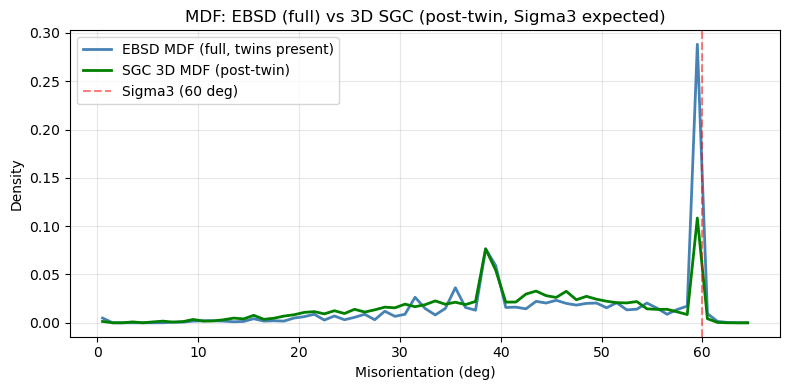

In [40]:
from upxo.xtalphy.crystal_orientation import compute_mdf_from_quats
from upxo.gsdataops.gid_ops import find_neighs3d

neigh_clean_raw = find_neighs3d(cleaner.lgi_clean.astype(np.int32), conn=6)
neigh_clean = {int(g): [int(n) for n in ns] for g, ns in neigh_clean_raw.items()}
sgc_mdf_post = compute_mdf_from_quats(
    cleaner.lgi_clean, quat_3d_clean, neigh_clean, n_bins=65, angle_range=(0.0, 65.0))

print(f'Post-twin MDF mean: {sgc_mdf_post["mean_angle"]:.2f} deg')

fig, ax = plt.subplots(figsize=(8, 4))
if isinstance(mdf, dict):
    ax.plot(mdf['hist_bin_centers'], mdf['hist_density'], label='EBSD MDF (full, twins present)', color='steelblue', lw=2)
else:
    ax.hist(mdf, bins=65, range=(0,65), density=True, alpha=0.5, label='EBSD MDF (full, twins present)', color='steelblue')
ax.plot(sgc_mdf_post['hist_bin_centers'], sgc_mdf_post['hist_density'],
        label='SGC 3D MDF (post-twin)', color='green', lw=2)
ax.axvline(60.0, color='red', linestyle='--', alpha=0.5, label='Sigma3 (60 deg)')
ax.set_xlabel('Misorientation (deg)'); ax.set_ylabel('Density')
ax.set_title('MDF: EBSD (full) vs 3D SGC (post-twin, Sigma3 expected)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### S33b1  MDF slice analysis -- configuration and computation
Defines slicing grid (independent of S21 morphological slicing), computes the
MDF for every evenly-spaced slice, and stores results for S33b2/S33b3 plots.
Set `ENABLE_MDF_SLICE_ANALYSIS = False` to skip the expensive step and keep
the last cached `_results` list.


In [41]:
from upxo.xtalphy.crystal_orientation import compute_mdf_from_quats
from upxo.gsdataops.gid_ops import find_neighs2d
import time

# -- S33b slicing configuration (independent of S21/S22) --------------------
MDF_N_SLICES_X = 50    # X-normal slices for MDF analysis
MDF_N_SLICES_Y = 50    # Y-normal slices
MDF_N_SLICES_Z = 50    # Z-normal slices

# +-MDF_TWIN_VF_TOL (relative) around EBSD twin VF used in S33b2 Plot 1
MDF_TWIN_VF_TOL = 0.30

# Number of top-Sigma3 slices shown in S33b3 Plot 2
MDF_TOP_N_SIGMA3 = 5

# False = skip computation; last cached _results list is kept
ENABLE_MDF_SLICE_ANALYSIS = True

# -- Standard FCC CSL reference angles (hardcoded, red dotted in plots) -----
_CSL_HARD = {
    'S3':   60.000,
    'S5':   36.870,
    'S7':   38.213,
    'S9':   38.942,
    'S11':  50.479,
    'S13a': 22.620,
    'S13b': 27.796,
    'S17a': 28.072,
    'S19a': 26.531,
    'S19b': 46.827,
    'S27a': 31.560,
    'S27b': 35.264,
}

# EBSD-detected peaks from S5 (green dashed in plots)
_peaks_angles = peaks.get('peak_angles', []) if isinstance(peaks, dict) else []
_peaks_labels = peaks.get('peak_labels', []) if isinstance(peaks, dict) else []

_ebsd_tvf  = tvf['overall_twin_frac']
_twin_gids = frozenset(
    gid for gid, role in cleaner.twin_role_clean.items()
    if role in ('primary_twin', 'secondary_twin'))

_ebsd_miso = mdf['miso_deg'] if isinstance(mdf, dict) else np.asarray(mdf)
_h_ebsd, _e_ebsd = np.histogram(_ebsd_miso, bins=65, range=(0., 65.), density=True)
_c_ebsd = 0.5 * (_e_ebsd[:-1] + _e_ebsd[1:])

_ax_colors = {'X': 'tomato', 'Y': 'steelblue', 'Z': 'seagreen'}

# ---- shared helper: overlay CSL reference lines ---------------------------
def _add_csl_lines(ax):
    from matplotlib.lines import Line2D
    _ymax = ax.get_ylim()[1]
    # Hardcoded: red dotted, angle labelled
    for lbl, ang in _CSL_HARD.items():
        ax.axvline(ang, color='crimson', lw=0.7, ls=':', alpha=0.55, zorder=1)
        ax.text(ang + 0.3, _ymax * 0.97, lbl + chr(10) + str(round(ang, 1)),
                fontsize=4.5, color='crimson', va='top', ha='left',
                rotation=90, clip_on=True)
    # EBSD-detected: green dashed, labelled
    for ang, lbl in zip(_peaks_angles, _peaks_labels):
        ax.axvline(ang, color='seagreen', lw=1.1, ls='--', alpha=0.75, zorder=2)
        ax.text(ang - 0.4, _ymax * 0.97, lbl + chr(10) + str(round(ang, 1)),
                fontsize=5, color='seagreen', va='top', ha='right',
                rotation=90, clip_on=True)
    return [
        Line2D([0],[0], color='crimson',  lw=0.9, ls=':',
               label='Standard FCC CSL angles (hardcoded, red dotted)'),
        Line2D([0],[0], color='seagreen', lw=1.1, ls='--',
               label='EBSD-detected MDF peaks from S5 (green dashed)'),
    ]

def _sigma3_density(mdf_dict, angle=60.0, half=1.0):
    c, d = mdf_dict['hist_bin_centers'], mdf_dict['hist_density']
    mask = np.abs(c - angle) <= half
    return float(d[mask].max()) if mask.any() else 0.0

# ---- compute slice MDFs ---------------------------------------------------
if not ENABLE_MDF_SLICE_ANALYSIS:
    print('[S33b1] Skipped -- using cached _results list.')
else:
    _axis_spec = [('X', 0, MDF_N_SLICES_X),
                  ('Y', 1, MDF_N_SLICES_Y),
                  ('Z', 2, MDF_N_SLICES_Z)]
    _total = sum(n for _, _, n in _axis_spec)
    _results, _done = [], 0
    _t0 = time.perf_counter()
    print(f'[S33b1] Computing MDFs for {_total} slices '
          f'(X:{MDF_N_SLICES_X}  Y:{MDF_N_SLICES_Y}  Z:{MDF_N_SLICES_Z})...')

    for _aname, _aint, _nsl in _axis_spec:
        _dom = cleaner.lgi_clean.shape[_aint]
        for _pos in np.linspace(0, _dom - 1, _nsl, dtype=int):
            _done += 1
            print(f'  [{_done:>3d}/{_total}] {_aname}-normal  pos={_pos:<4d}  '
                  f'elapsed={time.perf_counter()-_t0:.1f}s', end='\r', flush=True)

            if _aint == 0:   lgi2, q2 = cleaner.lgi_clean[_pos,:,:],  quat_3d_clean[_pos,:,:]
            elif _aint == 1: lgi2, q2 = cleaner.lgi_clean[:,_pos,:],  quat_3d_clean[:,_pos,:]
            else:            lgi2, q2 = cleaner.lgi_clean[:,:,_pos],  quat_3d_clean[:,:,_pos]

            if lgi2.max() <= 0: continue
            try:
                _nb  = {int(g): [int(n) for n in ns]
                        for g, ns in find_neighs2d(lgi2.astype(np.int32), conn=4).items()}
                _mdf = compute_mdf_from_quats(
                    lgi2, q2, _nb, n_bins=65, angle_range=(0., 65.))
                _tvf = float(np.isin(lgi2, list(_twin_gids)).sum()) / lgi2.size
                _results.append({
                    'axis': _aname, 'aint': _aint, 'pos': int(_pos),
                    'mdf':            _mdf,
                    'twin_vf':        _tvf,
                    'sigma3_density': _sigma3_density(_mdf),
                })
            except Exception:
                pass

    print(f'\n[S33b1] Complete -- {len(_results)}/{_total} slices  '
          f'total={time.perf_counter()-_t0:.1f}s')
    print(f'         Sigma3 density range: '
          f'{min(r["sigma3_density"] for r in _results):.4f}'
          f' -- {max(r["sigma3_density"] for r in _results):.4f}')
    print(f'         Twin VF range: '
          f'{min(r["twin_vf"] for r in _results):.4f}'
          f' -- {max(r["twin_vf"] for r in _results):.4f}'
          f'  (EBSD={_ebsd_tvf:.4f})')


[S33b1] Computing MDFs for 150 slices (X:50  Y:50  Z:50)...
  [150/150] Z-normal  pos=99    elapsed=20.1s
[S33b1] Complete -- 150/150 slices  total=20.2s
         Sigma3 density range: 0.0323 -- 0.1375
         Twin VF range: 0.0183 -- 0.1211  (EBSD=0.0574)


### S33b2  MDF of slices with twin VF closest to EBSD
Selects slices from `_results` whose twin area fraction lies within
`+-MDF_TWIN_VF_TOL` (relative) of the EBSD overall twin VF.
Individual slice curves are shown at low opacity; the per-axis mean is thick.


[S33b2] 113 slices with twin VF in [0.0402, 0.0746]  (EBSD=0.0574  +-30%)


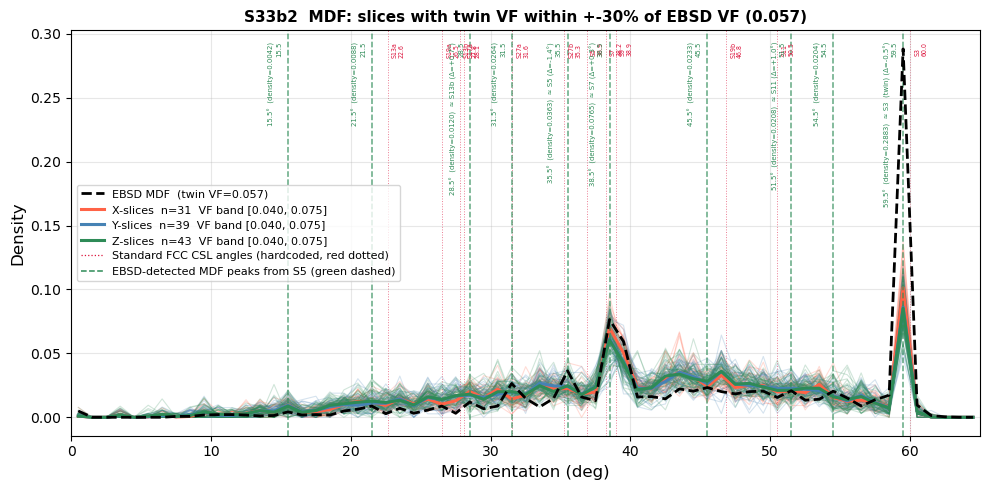

In [42]:
_lo = _ebsd_tvf * (1.0 - MDF_TWIN_VF_TOL)
_hi = _ebsd_tvf * (1.0 + MDF_TWIN_VF_TOL)
_vf_match = [r for r in _results if _lo <= r['twin_vf'] <= _hi]
print(f'[S33b2] {len(_vf_match)} slices with twin VF in '
      f'[{_lo:.4f}, {_hi:.4f}]  (EBSD={_ebsd_tvf:.4f}  '
      f'+-{MDF_TWIN_VF_TOL*100:.0f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(_c_ebsd, _h_ebsd, color='black', lw=2, ls='--',
        label=f'EBSD MDF  (twin VF={_ebsd_tvf:.3f})', zorder=10)

for r in _vf_match:
    ax.plot(r['mdf']['hist_bin_centers'], r['mdf']['hist_density'],
            color=_ax_colors[r['axis']], alpha=0.22, lw=0.8)
for _an, _col in _ax_colors.items():
    _grp = [r for r in _vf_match if r['axis'] == _an]
    if _grp:
        _md = np.mean([r['mdf']['hist_density'] for r in _grp], axis=0)
        ax.plot(_grp[0]['mdf']['hist_bin_centers'], _md, color=_col, lw=2.2,
                label=f'{_an}-slices  n={len(_grp)}  '
                      f'VF band [{_lo:.3f}, {_hi:.3f}]')

ax.set_xlim(0, 65)
ax.set_xlabel('Misorientation (deg)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'S33b2  MDF: slices with twin VF within '
             f'+-{MDF_TWIN_VF_TOL*100:.0f}% of EBSD VF ({_ebsd_tvf:.3f})',
             fontsize=11, fontweight='bold')
_prx = _add_csl_lines(ax)
_hh, _ll = ax.get_legend_handles_labels()
ax.legend(handles=_hh + _prx, fontsize=8)
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### S33b3  MDF of top slices by Sigma3 peak density
Ranks all computed slices by the maximum MDF density in the +-1 deg window
around the Sigma3 angle (60 deg), and plots the top `MDF_TOP_N_SIGMA3` curves
individually alongside the EBSD reference.


[S33b3] Top 5 slices by Sigma3 peak density:
  # 1  X-normal  pos=  16  Sigma3=0.1375  twin_VF=0.0691
  # 2  X-normal  pos=  99  Sigma3=0.1362  twin_VF=0.1211
  # 3  X-normal  pos=  14  Sigma3=0.1349  twin_VF=0.0715
  # 4  X-normal  pos=  18  Sigma3=0.1311  twin_VF=0.0673
  # 5  X-normal  pos=  12  Sigma3=0.1269  twin_VF=0.0750


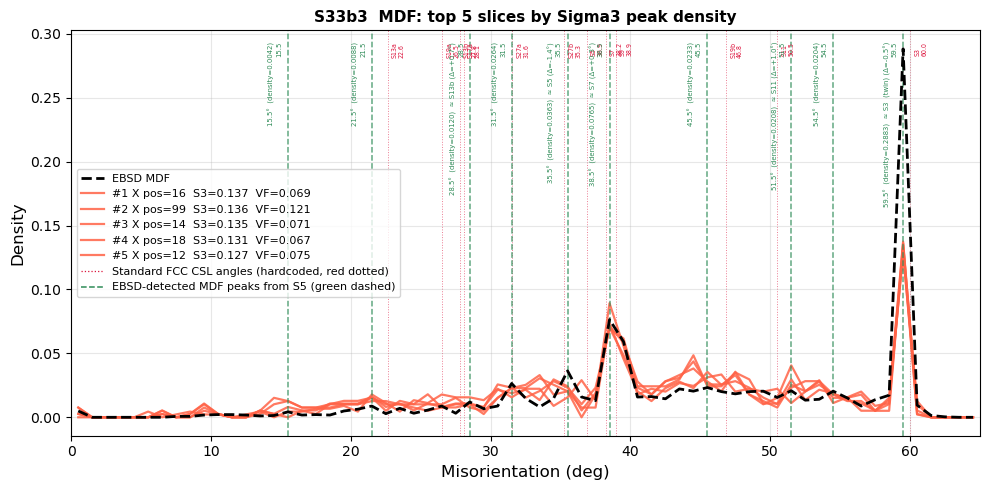

In [43]:
_top = sorted(_results, key=lambda r: r['sigma3_density'], reverse=True)[:MDF_TOP_N_SIGMA3]
print(f'[S33b3] Top {MDF_TOP_N_SIGMA3} slices by Sigma3 peak density:')
for _k, _r in enumerate(_top):
    print(f'  #{_k+1:>2d}  {_r["axis"]}-normal  pos={_r["pos"]:>4d}  '
          f'Sigma3={_r["sigma3_density"]:.4f}  twin_VF={_r["twin_vf"]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(_c_ebsd, _h_ebsd, color='black', lw=2, ls='--',
        label='EBSD MDF', zorder=10)
for _k, _r in enumerate(_top):
    ax.plot(_r['mdf']['hist_bin_centers'], _r['mdf']['hist_density'],
            color=_ax_colors[_r['axis']], lw=1.6, alpha=0.85,
            label=f'#{_k+1} {_r["axis"]} pos={_r["pos"]}  '
                  f'S3={_r["sigma3_density"]:.3f}  VF={_r["twin_vf"]:.3f}')

ax.set_xlim(0, 65)
ax.set_xlabel('Misorientation (deg)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'S33b3  MDF: top {MDF_TOP_N_SIGMA3} slices by Sigma3 peak density',
             fontsize=11, fontweight='bold')
_prx = _add_csl_lines(ax)
_hh, _ll = ax.get_legend_handles_labels()
ax.legend(handles=_hh + _prx, fontsize=8)
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### S33c  Twin thickness distributions - 2D slices vs EBSD reference
For each 2D slice (same X/Y/Z axis configuration as Parts D and G),
the minor-axis length of every twin region visible in that slice is
computed as a thickness proxy and converted to microns.  Thin lines
show individual slice distributions; thick lines show the per-axis
mean.  The EBSD reference (black dashed) is from twin_thickness[thick_um]
(S28).

Colour key: X-normal = red, Y-normal = blue, Z-normal = green.
Reuses N_SLICES_X/Y/Z and TEST_ALONG_X/Y/Z from Part D.

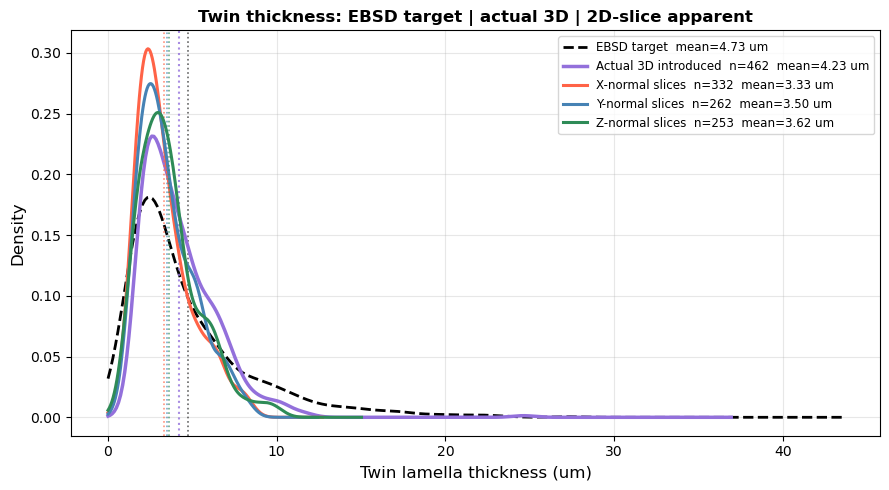

EBSD target mean   : 4.733 um
Actual 3D mean     : 4.235 um  (ratio to EBSD: 0.89x)


In [44]:
from scipy.stats import gaussian_kde
from skimage.measure import regionprops
from upxo.gsdataops.grid_ops import section_from_3d

axis_colors = {'X': 'tomato', 'Y': 'steelblue', 'Z': 'seagreen'}
axis_cfg    = [
    ('X', 0, N_SLICES_X, TEST_ALONG_X),
    ('Y', 1, N_SLICES_Y, TEST_ALONG_Y),
    ('Z', 2, N_SLICES_Z, TEST_ALONG_Z),
]
twin_role_set = {'primary_twin', 'secondary_twin'}

# EBSD reference
ebsd_thick  = twin_thickness['thick_um']
ebsd_mean_t = float(np.mean(ebsd_thick)) if ebsd_thick.size > 0 else 0.0

# Actual 3D introduced thicknesses (stored during twin introduction)
# twin_halfwidths_vox stores hw per twin grain ID; full thickness = 2 * hw * vox_size
actual_thick_um = np.array([
    2.0 * hw * pxt.vox_size
    for hw in twinmake.twin_halfwidths_vox.values()
])
actual_mean_t = float(np.mean(actual_thick_um)) if actual_thick_um.size > 0 else 0.0

fig, ax = plt.subplots(figsize=(9, 5))

# ── EBSD reference KDE (black dashed) ─────────────────────────────────────
if ebsd_thick.size > 1:
    x_ref   = np.linspace(0, max(ebsd_thick.max(), actual_thick_um.max() if actual_thick_um.size > 0 else 0) * 1.6, 300)
    kde_ref = gaussian_kde(ebsd_thick)
    ax.plot(x_ref, kde_ref(x_ref), color='black', lw=2, linestyle='--',
            label=f'EBSD target  mean={ebsd_mean_t:.2f} um')
    ax.axvline(ebsd_mean_t, color='black', lw=1.2, linestyle=':', alpha=0.6)

# ── Actual 3D introduced thickness KDE (purple solid) ─────────────────────
if actual_thick_um.size > 1:
    kde_act = gaussian_kde(actual_thick_um)
    x_act   = np.linspace(0, actual_thick_um.max() * 1.5, 300)
    ax.plot(x_act, kde_act(x_act), color='mediumpurple', lw=2.5, linestyle='-',
            label=f'Actual 3D introduced  n={actual_thick_um.size}  '
                  f'mean={actual_mean_t:.2f} um')
    ax.axvline(actual_mean_t, color='mediumpurple', lw=1.5, linestyle=':', alpha=0.8)

# ── Per-axis 2D apparent thickness from regionprops (red / blue / green) ──
for axis_name, ax_int, n_slices, test_enabled in axis_cfg:
    if not test_enabled:
        continue
    color = axis_colors[axis_name]
    domain_size   = cleaner.lgi_clean.shape[ax_int]
    slice_indices = np.linspace(0, domain_size - 1, n_slices, dtype=int)

    all_thick_um = []
    slice_kdes   = []
    x_plot       = None

    for slice_idx in slice_indices:
        lgi_2d = section_from_3d(cleaner.lgi_clean, axis=ax_int,
                                  location=int(slice_idx))
        slice_gids = set(int(g) for g in np.unique(lgi_2d) if g > 0)
        twin_gids  = slice_gids & {
            g for g, r in cleaner.twin_role_clean.items() if r in twin_role_set}

        for gid in twin_gids:
            mask = (lgi_2d == gid)
            if np.sum(mask) < 4:
                continue
            rp = regionprops(mask.astype(np.uint8))
            if rp and rp[0].minor_axis_length > 0:
                all_thick_um.append(rp[0].minor_axis_length * pxt.vox_size)

    if len(all_thick_um) > 1:
        arr   = np.array(all_thick_um)
        mean_t = float(np.mean(arr))
        x_hi   = max(arr.max() * 1.5, 0.1)
        x_s    = np.linspace(0, x_hi, 200)
        kde_s  = gaussian_kde(arr)
        ax.plot(x_s, kde_s(x_s), color=color, lw=2.2,
                label=f'{axis_name}-normal slices  n={len(all_thick_um)}  '
                      f'mean={mean_t:.2f} um')
        ax.axvline(mean_t, color=color, lw=1.2, linestyle=':', alpha=0.7)
    else:
        print(f'{axis_name}-axis: insufficient twin data in slices.')

ax.set_xlabel('Twin lamella thickness (um)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Twin thickness: EBSD target | actual 3D | 2D-slice apparent',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'EBSD target mean   : {ebsd_mean_t:.3f} um')
print(f'Actual 3D mean     : {actual_mean_t:.3f} um  '
      f'(ratio to EBSD: {actual_mean_t/ebsd_mean_t:.2f}x)' if ebsd_mean_t > 0 else '')

## Part H - Visualisation and export

### S34  3D PyVista render

In [45]:
from upxo.pxtal.twinned_simple_3d.viz_3d import render_3d
render_3d(cleaner.lgi_clean, cleaner.twin_role_clean, role_opacity={'non_host': 0.60, 
                                                                    'host': 0.75,
                                                                    'primary_twin': 1.0,
                                                                    'secondary_twin': 1.0})

Widget(value='<iframe src="http://localhost:55328/index.html?ui=P_0x1f1bab67b60_0&reconnect=auto" class="pyvis…

### S35  IPF-coloured 2D slice

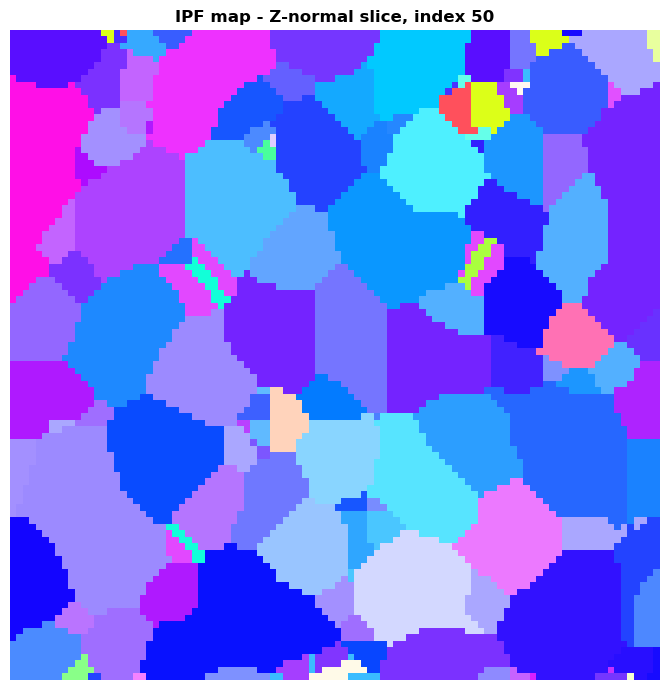

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'IPF map - Z-normal slice, index 50'}>)

In [46]:
from upxo.pxtal.twinned_simple_3d.viz_3d import plot_ipf_slice

VIZ_AXIS = 2  # 0=X, 1=Y, 2=Z
plot_ipf_slice(cleaner.lgi_clean, cleaner.all_quats_clean, axis=VIZ_AXIS)

### S36a  Export final structure to disk (numpy / pickle)


In [47]:
import os, pickle, time as _t

OUT_DIR_3D = r'C:/Development/UPXO/upxo_library/data/gs'
os.makedirs(OUT_DIR_3D, exist_ok=True)

_t0 = _t.perf_counter()
print('[S36a] Exporting structure to disk...')

# Auto-select optimal integer dtype based on max grain ID
_max_gid = int(cleaner.lgi_clean.max())
import numpy as np
if _max_gid < np.iinfo(np.uint16).max:    # < 65535
    _lgi_dtype = np.uint16
elif _max_gid < np.iinfo(np.int32).max:   # < 2147483647
    _lgi_dtype = np.int32
else:
    _lgi_dtype = np.int64
print(f'  max_gid={_max_gid}  -> dtype={_lgi_dtype.__name__}  '
      f'(saves {cleaner.lgi_clean.nbytes // 1024**2} MB uncompressed)')

# LGI: compressed npz (uint16 for typical domains saves ~75% vs float64)
print('  Step 1/4  lgi_twinned_clean.npz...', end='', flush=True)
_t1 = _t.perf_counter()
np.savez_compressed(os.path.join(OUT_DIR_3D, 'lgi_twinned_clean.npz'),
                    lgi=cleaner.lgi_clean.astype(_lgi_dtype))
print(f'  done ({_t.perf_counter()-_t1:.1f}s)')

# Quaternions: compressed npz
print('  Step 2/4  quat_3d_clean.npz...', end='', flush=True)
_t2 = _t.perf_counter()
np.savez_compressed(os.path.join(OUT_DIR_3D, 'quat_3d_clean.npz'),
                    quat=quat_3d_clean.astype(np.float32))
print(f'  done ({_t.perf_counter()-_t2:.1f}s)')

# Dicts: pickle (small, fast)
print('  Step 3/4  orientations_all.pkl...', end='', flush=True)
_t3 = _t.perf_counter()
with open(os.path.join(OUT_DIR_3D, 'orientations_all.pkl'), 'wb') as _f:
    pickle.dump(cleaner.all_quats_clean, _f, protocol=4)
print(f'  done ({_t.perf_counter()-_t3:.1f}s)')

print('  Step 4/4  role + parent dicts...', end='', flush=True)
_t4 = _t.perf_counter()
with open(os.path.join(OUT_DIR_3D, 'twin_role.pkl'), 'wb') as _f:
    pickle.dump(cleaner.twin_role_clean, _f, protocol=4)
with open(os.path.join(OUT_DIR_3D, 'twin_parent_of.pkl'), 'wb') as _f:
    pickle.dump(cleaner.twin_parent_of_clean, _f, protocol=4)
print(f'  done ({_t.perf_counter()-_t4:.1f}s)')

print(f'[S36a] Complete  total={_t.perf_counter()-_t0:.1f}s  --> {OUT_DIR_3D}')


[S36a] Exporting structure to disk...
  max_gid=1596  -> dtype=uint16  (saves 3 MB uncompressed)
  Step 1/4  lgi_twinned_clean.npz...  done (0.1s)
  Step 2/4  quat_3d_clean.npz...  done (0.2s)
  Step 3/4  orientations_all.pkl...  done (0.0s)
  Step 4/4  role + parent dicts...  done (0.0s)
[S36a] Complete  total=0.3s  --> C:/Development/UPXO/upxo_library/data/gs


### S36b  Export Abaqus input file
Writes a partitioned Abaqus `.inp` model from the cleaned twinned structure.
Follows the FM Steel multi-file convention (master + included sub-files):
```
model_master.inp
  01_nodes.inp
  02_elements.inp
  03a_elsets_cells.inp   -- per-grain cell ELSETs (material assignment, no voxel overlap)
  03b_elsets_roles.inp      -- role grouping ELSETs (Option 2, deduplication allowed)
  03c_elsets_families.inp   -- parent-twin family ELSETs (Option 3, user flag)
  03d_elsets_variants.inp   -- Sigma3 variant ELSETs (Option 5, user flag)
  04_nsets_bc.inp
  05_materials.inp          -- one *Material per grain (Bunge-Euler angles)
  06_sections.inp           -- *Solid Section linking 03a ELSETs to 05 materials
  07_interactions.inp
  08_steps_output.inp
```
ELSET naming (03a, material assignment):
  `es.cell.nonpart.<gid>` | `es.cell.host.<gid>` | `es.cell.ptwin.<gid>`
  `es.cell.stwin.a.<gid>` (2a outward: parent = host grain)
  `es.cell.stwin.b.<gid>` (2b inward: parent = primary twin)
Material naming: `MAT.CELL.NONPART.<gid>` etc. matching ELSET names.


In [48]:
from upxo.pxtal.twinned_simple_3d.abaqus_exporter_3d import AbaqusExporter3D, DEFAULT_ABQ_OUT_DIR
import os

# -- Output directory -------------------------------------------------------
# Default resolves to upxo_library/data/ABQInputFiles/ofhcCu/ relative to package root.
# Override below if you want a different destination.
ABQ_OUT_DIR = DEFAULT_ABQ_OUT_DIR

# -- Element type -----------------------------------------------------------
# C3D8  = 8-node linear brick (voxel mesh, 1 element per voxel)
# C3D4  = 4-node linear tet (requires remeshing, not supported here)
ABQ_ELEMENT_TYPE = 'C3D8'

# -- Optional grouping ELSETs -----------------------------------------------
ABQ_WRITE_ROLE_ELSETS    = True    # 03b: ALL_HOST, ALL_PTWIN, etc. (Option 2)
ABQ_WRITE_FAMILY_ELSETS  = True    # 03c: host + its twins per family  (Option 3)
ABQ_WRITE_VARIANT_ELSETS = True    # 03d: primary twins by Sigma3 variant (Option 5)

# -- Material stub format ---------------------------------------------------
# 'bunge_euler' : *User Material with 3 constants (phi1, Phi, phi2) in degrees
# 'orientation' : *Orientation + *Elastic (for elastic-only studies)
ABQ_MATERIAL_FORMAT = 'bunge_euler'
ABQ_UMAT_N_DEPVAR   = 100     # number of state variables for UMAT

# -- Voxel size (for node coordinate scaling) -------------------------------
ABQ_VOXEL_SIZE_UM = base.voxel_size   # physical voxel edge length in microns

print('[S36b] Initialising AbaqusExporter3D...')
abq = AbaqusExporter3D(
    lgi                = cleaner.lgi_clean,
    twin_role          = cleaner.twin_role_clean,
    twin_parent_of     = cleaner.twin_parent_of_clean,
    all_quats          = cleaner.all_quats_clean,
    twinmake           = twinmake,            # for variant index access
    voxel_size_um      = ABQ_VOXEL_SIZE_UM,
    element_type       = ABQ_ELEMENT_TYPE,
    material_format    = ABQ_MATERIAL_FORMAT,
    n_depvar           = ABQ_UMAT_N_DEPVAR,
    write_role_elsets   = ABQ_WRITE_ROLE_ELSETS,
    write_family_elsets = ABQ_WRITE_FAMILY_ELSETS,
    write_variant_elsets= ABQ_WRITE_VARIANT_ELSETS,
)

print('[S36b] Writing Abaqus input files...')
abq.write(ABQ_OUT_DIR)
print(f'[S36b] Done  -->  {ABQ_OUT_DIR}')


[S36b] Initialising AbaqusExporter3D...
AbaqusExporter3D: indexing grain-to-element map...  done (0.7s)  1566 grains
[S36b] Writing Abaqus input files...
  Writing  01_nodes.inp...  done (2.8s)
  Writing  02_elements.inp...  done (6.2s)
  Writing  03a_elsets_cells.inp...  done (0.8s)
  Writing  03b_elsets_roles.inp...  done (1.1s)
  Writing  03c_elsets_families.inp...  done (0.2s)
  Writing  03d_elsets_variants.inp...  done (0.1s)
  Writing  04_nsets_bc.inp...  done (0.1s)
  Writing  05_materials.inp...  done (0.1s)
  Writing  06_sections.inp...  done (0.0s)
  Writing  07_interactions.inp...  done (0.0s)
  Writing  08_steps_output.inp...  done (0.0s)
AbaqusExporter3D.write: complete  total=11.4s
  Output: C:\Development\UPXO\upxo_library\data\ABQInputFiles\ofhcCu
[S36b] Done  -->  C:\Development\UPXO\upxo_library\data\ABQInputFiles\ofhcCu


### S37  Final summary report

In [49]:
from upxo.pxtal.twinned_simple_3d.feature_props_3d import (
    grain_role_statistics,
    compute_ebsd_mc_comparison_stats,
    print_ebsd_mc_comparison,
)
from upxo.gsdataops.grid_ops import section_from_3d
from skimage.measure import regionprops

# ── 1. Role statistics ───────────────────────────────────────────────────
vols       = {gid: int(np.sum(cleaner.lgi_clean == gid))
              for gid in (int(g) for g in np.unique(cleaner.lgi_clean) if g > 0)}
role_stats = grain_role_statistics(vols, cleaner.twin_role_clean, base.voxel_size)

# ── 2. EBSD reference dict ───────────────────────────────────────────────
# Fix: use rg.lfi_ebsd (original, not merged) for parent grain IDs
# Use S3 (twin) parents — physically the relevant host grain system
_host_csl = 'S3  (twin)' if 'S3  (twin)' in parent_info else tvf['csl_label']
ebsd_parent_gids = parent_info[_host_csl]['pure_parents']
ebsd_host_eqdia  = np.array([
    float(2.0 * np.sqrt(np.sum(rg.lfi_ebsd == gid)
                        * rg.ebsd_step**2 / np.pi))
    for gid in ebsd_parent_gids
    if np.sum(rg.lfi_ebsd == gid) > 0
])

ebsd_ref = {
    'miso_deg_full':   mdf['miso_deg'] if isinstance(mdf, dict) else mdf,
    'miso_deg_merged': mdf_merged['miso_deg'],
    'twin_thick_um':   twin_thickness['thick_um'],
    'host_eqdia_um':   ebsd_host_eqdia,
    'tvf_2d':          tvf['overall_twin_frac'],
}

# ── 3. MC reference dict ─────────────────────────────────────────────────
# MC apparent 2D thickness: regionprops minor_axis_length on slices
sgc_twin_thick_2d = []
twin_gids_set = {g for g, r in cleaner.twin_role_clean.items()
                  if r in ('primary_twin', 'secondary_twin')}
for _ax in range(3):
    for _idx in np.linspace(0, cleaner.lgi_clean.shape[_ax]-1, N_SLICES_X, dtype=int):
        _s = section_from_3d(cleaner.lgi_clean, axis=_ax, location=int(_idx))
        for _gid in (set(int(g) for g in np.unique(_s) if g > 0) & twin_gids_set):
            _mask = (_s == _gid)
            if np.sum(_mask) < 4: continue
            _rp = regionprops(_mask.astype(np.uint8))
            if _rp and _rp[0].minor_axis_length > 0:
                sgc_twin_thick_2d.append(_rp[0].minor_axis_length * pxt.vox_size)
sgc_twin_thick_2d = np.array(sgc_twin_thick_2d)

# MC actual 3D thickness from stored half-widths
sgc_twin_thick_3d = np.array([
    2.0 * hw * pxt.vox_size
    for hw in twinmake.twin_halfwidths_vox.values()
]) if twinmake.twin_halfwidths_vox else np.array([])

# MC host grain eq-diameters
sgc_host_eqdia = np.array([
    base.mprop['eqdia'][gid]
    for gid in base.host_grain_ids
    if gid in base.mprop.get('eqdia', {})
]) if base.host_grain_ids else np.array([])

# Per-slice 2D twin VF
tvf_2d_slices = []
for _ax in range(3):
    _dom = cleaner.lgi_clean.shape[_ax]
    for _idx in np.linspace(0, _dom - 1, N_SLICES_X, dtype=int):
        _s   = section_from_3d(cleaner.lgi_clean, axis=_ax, location=int(_idx))
        _tot = int(np.sum(_s > 0))
        _twn = int(np.sum(np.isin(_s, list(twin_gids_set))))
        if _tot > 0:
            tvf_2d_slices.append(_twn / _tot)

# -- Final twin VF from cleaned structure --------------------------------
twin_gids_final = {g for g, r in cleaner.twin_role_clean.items()
                    if r in ("primary_twin", "secondary_twin")}
_tot_clean = int(np.sum(cleaner.lgi_clean > 0))
_twin_clean = sum(int(np.sum(cleaner.lgi_clean == g)) for g in twin_gids_final)
tvf_final_3d = _twin_clean / _tot_clean if _tot_clean > 0 else 0.0

sgc_ref = {
    'miso_deg_posttwin':        sgc_mdf_post['miso_deg'],
    'twin_thick_apparent_2d_um': sgc_twin_thick_2d,
    'twin_thick_3d_um':          sgc_twin_thick_3d,
    'host_eqdia_um':             sgc_host_eqdia,
    'tvf_2d_slices':             np.array(tvf_2d_slices),
    'tvf_3d':                    tvf_final_3d,   # final, post-cleaning
}

# ── 4. Print comparison ──────────────────────────────────────────────────
cmp_stats = compute_ebsd_mc_comparison_stats(ebsd_ref, sgc_ref)
print_ebsd_mc_comparison(cmp_stats)

# ── 5. Role volume stats ─────────────────────────────────────────────────
print('\nGRAIN ROLE VOLUME STATISTICS (MC)')
print('-' * 72)
for role, st in role_stats.items():
    print(f'  {role:<18} n={st["count"]:>4}  '
          f'mean={st["mean_vol_um3"]:>8.1f}  '
          f'std={st["std_vol_um3"]:>8.1f} um3')

print('\nPipeline complete: Parts A-H.')

print('\nFINAL TWIN VOLUME FRACTION  (post-cleaning, authoritative)')
print('-' * 72)
_n_prim = len([g for g,r in cleaner.twin_role_clean.items() if r=='primary_twin'])
_n_sec  = len([g for g,r in cleaner.twin_role_clean.items() if r=='secondary_twin'])
print(f'  Primary twins        : {_n_prim} grains')
print(f'  Secondary twins      : {_n_sec} grains')
print(f'  Twin voxels          : {_twin_clean:,}')
print(f'  Total domain voxels  : {_tot_clean:,}')
print(f'  Twin VF (3D, final)  : {tvf_final_3d:.4f}   ({100*tvf_final_3d:.2f}%)')
_ebsd_tvf = tvf['overall_twin_frac']
print(f'  EBSD 2D area frac    : {_ebsd_tvf:.4f}   ({100*_ebsd_tvf:.2f}%)')
print(f'  Ratio  3D / 2D       : {tvf_final_3d/_ebsd_tvf:.3f}x')

# -- Total notebook elapsed time ----------------------------------------
import time as _nb_time
if '_NOTEBOOK_T0' in dir():
    _elapsed = _nb_time.perf_counter() - _NOTEBOOK_T0
    print(f'{'='*72}')
    print(f'TOTAL NOTEBOOK ELAPSED TIME: {_elapsed/60:.1f} min  ({_elapsed:.0f}s)')
    print(f'{'='*72}')


EBSD vs Synthetic MC  --  Statistical Comparison

MISORIENTATION DISTRIBUTION (MDF)
Property                            EBSD (full)  EBSD (merged)  SGC post-twin
------------------------------------------------------------------------
  Mean                                   46.18       39.10       41.29  deg
  Std dev                                12.69       12.02       12.40  deg
  Q1                                     38.42       31.68       33.62  deg
  Median                                 46.88       40.94       41.35  deg
  Q3                                     59.63       47.96       50.55  deg
  n (boundary pairs)                      2837         363        8649

TWIN LAMELLA THICKNESS  (EBSD=2D apparent; MC apparent=regionprops on slices; MC actual=2xhw from introduction)
Property                            EBSD apparent 2D  SGC apparent 2D  SGC actual 3D
------------------------------------------------------------------------
  Mean                                    4